# Part I. Preregistered occlusion study
## Descriptives and primary confirmatory mixed-effects analysis

This notebook implements the Part I analysis for the preregistered occlusion study using a CSV input file.

### Principles of this notebook
- No cases are dropped.
- Rows are analyzed exactly as stored in the CSV, including rows where `is_correct_baseline = 0`.
- The main outcome is `target_logit_drop`.
- The primary confirmatory model is a linear mixed-effects model with a random intercept for `case_id`.
- Outputs are saved to disk for reproducibility and later integration into the larger preregistered pipeline.

### Expected columns
`case_id, model_type, placement_type, num_occluders, occluder_size, target_class, target_class_name, baseline_target_logit, post_occlusion_target_logit, target_logit_drop, is_correct_baseline, is_correct_post_occlusion, prediction_changed`

In [1]:
# Imports and global settings

from pathlib import Path
import warnings
import json
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import dmatrix

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# User-editable paths

DATA_PATH = Path("/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/tables/part1_robustness_long.csv")

OUTPUT_DIR = Path("part1_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

for p in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATA_PATH: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/tables/part1_robustness_long.csv
OUTPUT_DIR: /data/storage-occ-v2/repos/monte-carlo-selection/notebooks/part1_outputs


In [3]:
# Load data

df = pd.read_csv(DATA_PATH)

print("Loaded data from:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Loaded data from: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/tables/part1_robustness_long.csv
Shape: (5120, 13)


,case_id,model_type,placement_type,num_occluders,occluder_size,target_class,target_class_name,baseline_target_logit,post_occlusion_target_logit,target_logit_drop,is_correct_baseline,is_correct_post_occlusion,prediction_changed
0,ns_cow_202,resnet50_geirhos_tl,targeted,1,8,37,pig,7.092349,6.706945,0.385403,0,0,0
1,ns_cow_202,resnet50_geirhos_tl,targeted,2,8,37,pig,7.092349,6.410131,0.682218,0,0,0
2,ns_cow_202,resnet50_geirhos_tl,targeted,3,8,37,pig,7.092349,6.150289,0.942060,0,0,0
3,ns_cow_202,resnet50_geirhos_tl,targeted,4,8,37,pig,7.092349,6.135908,0.956441,0,0,0
4,ns_cow_202,resnet50_geirhos_tl,targeted,5,8,37,pig,7.092349,5.873656,1.218693,0,0,0


## Basic data audit

This section checks:
- shape
- column names
- data types
- missingness
- duplicate rows
- levels of key grouping variables
- range of `num_occluders`
- number of unique `case_id`s

These checks are descriptive only. No rows are removed.

In [4]:
# Basic audit

print("Shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values per column:")
missing_df = df.isna().sum().to_frame("n_missing")
display(missing_df)

n_duplicate_rows = int(df.duplicated().sum())
print("\nDuplicate full rows:", n_duplicate_rows)

print("\nUnique levels: model_type")
print(sorted(df["model_type"].dropna().astype(str).unique().tolist()))

print("\nUnique levels: placement_type")
print(sorted(df["placement_type"].dropna().astype(str).unique().tolist()))

print("\nUnique levels: occluder_size")
print(sorted(df["occluder_size"].dropna().unique().tolist()))

print("\nnum_occluders summary")
print("min:", df["num_occluders"].min())
print("max:", df["num_occluders"].max())
print("unique:", sorted(df["num_occluders"].dropna().unique().tolist()))

print("\nUnique case_id count:", df["case_id"].nunique())

Shape: (5120, 13)

Column names:
['case_id', 'model_type', 'placement_type', 'num_occluders', 'occluder_size', 'target_class', 'target_class_name', 'baseline_target_logit', 'post_occlusion_target_logit', 'target_logit_drop', 'is_correct_baseline', 'is_correct_post_occlusion', 'prediction_changed']

Dtypes:


,dtype
case_id,object
model_type,object
placement_type,object
num_occluders,int64
occluder_size,int64
target_class,int64
target_class_name,object
baseline_target_logit,float64
post_occlusion_target_logit,float64
target_logit_drop,float64



Missing values per column:


,n_missing
case_id,0
model_type,0
placement_type,0
num_occluders,0
occluder_size,0
target_class,0
target_class_name,0
baseline_target_logit,0
post_occlusion_target_logit,0
target_logit_drop,0



Duplicate full rows: 0

Unique levels: model_type
['resnet50_geirhos_tl', 'resnet50_tl_20250829']

Unique levels: placement_type
['random', 'targeted']

Unique levels: occluder_size
[8, 16, 32, 64]

num_occluders summary
min: 1
max: 8
unique: [1, 2, 3, 4, 5, 6, 7, 8]

Unique case_id count: 40


In [5]:
# Save audit tables

missing_df.to_csv(TABLE_DIR / "audit_missing_values.csv")

audit_levels = {
    "model_type_levels": sorted(df["model_type"].dropna().astype(str).unique().tolist()),
    "placement_type_levels": sorted(df["placement_type"].dropna().astype(str).unique().tolist()),
    "occluder_size_levels": sorted(pd.Series(df["occluder_size"].dropna().unique()).tolist()),
    "num_occluders_unique": sorted(pd.Series(df["num_occluders"].dropna().unique()).tolist()),
    "n_duplicate_rows": n_duplicate_rows,
    "n_unique_case_id": int(df["case_id"].nunique()),
    "shape": list(df.shape),
}

with open(MODEL_DIR / "audit_summary.json", "w") as f:
    json.dump(audit_levels, f, indent=2)

## Data preparation

The analysis dataset is prepared as follows:
- `model_type`, `placement_type`, and `occluder_size` are treated as categorical.
- `num_occluders` is treated as numeric.
- No rows are removed.
- Sanity-check summaries are created without altering the main analysis data.

In [6]:
# Data preparation without dropping rows

analysis_df = df.copy()

analysis_df["model_type"] = analysis_df["model_type"].astype("category")
analysis_df["placement_type"] = analysis_df["placement_type"].astype("category")
analysis_df["occluder_size"] = analysis_df["occluder_size"].astype("category")

analysis_df["num_occluders"] = pd.to_numeric(analysis_df["num_occluders"], errors="coerce")
analysis_df["target_logit_drop"] = pd.to_numeric(analysis_df["target_logit_drop"], errors="coerce")
analysis_df["baseline_target_logit"] = pd.to_numeric(analysis_df["baseline_target_logit"], errors="coerce")
analysis_df["post_occlusion_target_logit"] = pd.to_numeric(analysis_df["post_occlusion_target_logit"], errors="coerce")

print("Prepared dtypes:")
display(analysis_df.dtypes.to_frame("dtype"))

Prepared dtypes:


,dtype
case_id,object
model_type,category
placement_type,category
num_occluders,int64
occluder_size,category
target_class,int64
target_class_name,object
baseline_target_logit,float64
post_occlusion_target_logit,float64
target_logit_drop,float64


In [7]:
# Sanity-check summaries that do not alter the data

sanity_summary = {
    "n_rows": int(len(analysis_df)),
    "n_case_id": int(analysis_df["case_id"].nunique()),
    "n_model_type": int(analysis_df["model_type"].nunique()),
    "n_placement_type": int(analysis_df["placement_type"].nunique()),
    "n_occluder_size": int(analysis_df["occluder_size"].nunique()),
    "num_occluders_min": float(np.nanmin(analysis_df["num_occluders"])),
    "num_occluders_max": float(np.nanmax(analysis_df["num_occluders"])),
    "target_logit_drop_missing": int(analysis_df["target_logit_drop"].isna().sum()),
}

display(pd.Series(sanity_summary, name="value").to_frame())

with open(MODEL_DIR / "sanity_summary.json", "w") as f:
    json.dump(sanity_summary, f, indent=2)

,value
n_rows,5120.0
n_case_id,40.0
n_model_type,2.0
n_placement_type,2.0
n_occluder_size,4.0
num_occluders_min,1.0
num_occluders_max,8.0
target_logit_drop_missing,0.0


## Descriptive summaries

The following summaries describe `target_logit_drop`:
- overall
- by `model_type`
- by `placement_type`
- by `occluder_size`
- by `model_type × placement_type`
- by `model_type × placement_type × occluder_size`

In [8]:
# Helper for descriptive summaries

def descriptive_table(data, group_cols=None, value_col="target_logit_drop"):
    if group_cols is None or len(group_cols) == 0:
        out = pd.DataFrame({
            "n": [data[value_col].notna().sum()],
            "mean": [data[value_col].mean()],
            "sd": [data[value_col].std()],
            "median": [data[value_col].median()],
            "min": [data[value_col].min()],
            "max": [data[value_col].max()],
        })
    else:
        out = (
            data.groupby(group_cols, observed=True)[value_col]
            .agg(
                n="count",
                mean="mean",
                sd="std",
                median="median",
                min="min",
                max="max",
            )
            .reset_index()
        )
    return out

In [9]:
# Grouped descriptive summaries

desc_by_model = descriptive_table(analysis_df, ["model_type"])
desc_by_placement = descriptive_table(analysis_df, ["placement_type"])
desc_by_size = descriptive_table(analysis_df, ["occluder_size"])
desc_by_model_x_placement = descriptive_table(analysis_df, ["model_type", "placement_type"])
desc_by_model_x_placement_x_size = descriptive_table(
    analysis_df,
    ["model_type", "placement_type", "occluder_size"]
)

display(desc_by_model)
display(desc_by_placement)
display(desc_by_size)
display(desc_by_model_x_placement.head(20))
display(desc_by_model_x_placement_x_size.head(20))

desc_by_model.to_csv(TABLE_DIR / "desc_by_model_type.csv", index=False)
desc_by_placement.to_csv(TABLE_DIR / "desc_by_placement_type.csv", index=False)
desc_by_size.to_csv(TABLE_DIR / "desc_by_occluder_size.csv", index=False)
desc_by_model_x_placement.to_csv(TABLE_DIR / "desc_by_model_x_placement.csv", index=False)
desc_by_model_x_placement_x_size.to_csv(TABLE_DIR / "desc_by_model_x_placement_x_occluder_size.csv", index=False)

,model_type,n,mean,sd,median,min,max
0,resnet50_geirhos_tl,2560,2.048154,2.094264,1.524292,-1.985846,9.869479
1,resnet50_tl_20250829,2560,17.321926,21.609132,7.007042,-0.275497,95.394775


,placement_type,n,mean,sd,median,min,max
0,random,2560,7.175051,15.020800,1.274628,-1.985846,95.394775
1,targeted,2560,12.195028,18.702961,4.323196,-0.105682,94.083729


,occluder_size,n,mean,sd,median,min,max
0,8,1280,1.363160,1.631578,0.862946,-1.415815,9.697853
1,16,1280,3.136757,3.363275,2.146619,-1.491307,15.748581
2,32,1280,9.644512,10.482753,4.717664,-1.741309,44.013054
3,64,1280,24.595730,26.794268,7.394743,-1.985846,95.394775


,model_type,placement_type,n,mean,sd,median,min,max
0,resnet50_geirhos_tl,random,1280,1.125008,1.821505,0.353242,-1.985846,9.273841
1,resnet50_geirhos_tl,targeted,1280,2.971299,1.936931,2.624756,-0.105682,9.869479
2,resnet50_tl_20250829,random,1280,13.225094,19.360891,4.043228,-0.275497,95.394775
3,resnet50_tl_20250829,targeted,1280,21.418758,22.931111,11.175705,0.744553,94.083729


,model_type,placement_type,occluder_size,n,mean,sd,median,min,max
0,resnet50_geirhos_tl,random,8,320,-0.002258,0.360854,0.006216,-1.415815,1.403388
1,resnet50_geirhos_tl,random,16,320,0.167622,0.527874,0.141515,-1.491307,2.170761
2,resnet50_geirhos_tl,random,32,320,0.993997,1.233134,0.776497,-1.741309,6.040606
3,resnet50_geirhos_tl,random,64,320,3.340672,2.058470,3.279184,-1.985846,9.273841
4,resnet50_geirhos_tl,targeted,8,320,1.137481,0.574346,1.079159,-0.105682,3.241194
5,resnet50_geirhos_tl,targeted,16,320,2.186474,0.977119,2.082329,0.448868,6.091955
6,resnet50_geirhos_tl,targeted,32,320,3.793813,1.524458,3.732160,0.909545,9.370882
7,resnet50_geirhos_tl,targeted,64,320,4.767429,1.878118,4.562732,0.965345,9.869479
8,resnet50_tl_20250829,random,8,320,0.740672,0.513523,0.656906,-0.228928,2.729492
9,resnet50_tl_20250829,random,16,320,2.688128,1.696330,2.645187,-0.275497,6.085114


In [10]:
# Additional sanity summary relevant to interpretation, but not used to filter data

status_summary = (
    analysis_df
    .groupby(["model_type", "placement_type", "occluder_size"], observed=True)
    .agg(
        n=("case_id", "size"),
        mean_correct_baseline=("is_correct_baseline", "mean"),
        mean_correct_post_occlusion=("is_correct_post_occlusion", "mean"),
        mean_prediction_changed=("prediction_changed", "mean"),
    )
    .reset_index()
)

display(status_summary.head(20))
status_summary.to_csv(TABLE_DIR / "sanity_status_summary.csv", index=False)

,model_type,placement_type,occluder_size,n,mean_correct_baseline,mean_correct_post_occlusion,mean_prediction_changed
0,resnet50_geirhos_tl,random,8,320,0.625,0.568750,0.162500
1,resnet50_geirhos_tl,random,16,320,0.625,0.537500,0.250000
2,resnet50_geirhos_tl,random,32,320,0.625,0.446875,0.393750
3,resnet50_geirhos_tl,random,64,320,0.625,0.212500,0.759375
4,resnet50_geirhos_tl,targeted,8,320,0.625,0.493750,0.440625
5,resnet50_geirhos_tl,targeted,16,320,0.625,0.331250,0.671875
6,resnet50_geirhos_tl,targeted,32,320,0.625,0.159375,0.837500
7,resnet50_geirhos_tl,targeted,64,320,0.625,0.046875,0.953125
8,resnet50_tl_20250829,random,8,320,0.125,0.125000,0.000000
9,resnet50_tl_20250829,random,16,320,0.125,0.125000,0.000000


## Descriptive plots

These plots are descriptive and intended to support interpretation of the confirmatory model:
1. Mean `target_logit_drop` across `num_occluders`, with separate lines for `model_type`, line style by `placement_type`, and panels by `occluder_size`.
2. Distribution of `target_logit_drop` by `placement_type`, split by `model_type`.
3. Mean `target_logit_drop` across `occluder_size`, separated by `model_type` and `placement_type`.
4. Case-level means by model as a simple view of between-case spread.

In [11]:
# Plot helper settings

model_levels = list(analysis_df["model_type"].cat.categories)
placement_levels = list(analysis_df["placement_type"].cat.categories)
size_levels = list(analysis_df["occluder_size"].cat.categories)

line_styles = ["-", "--", ":", "-."]
marker_styles = ["o", "s", "^", "D", "v", "P", "X"]

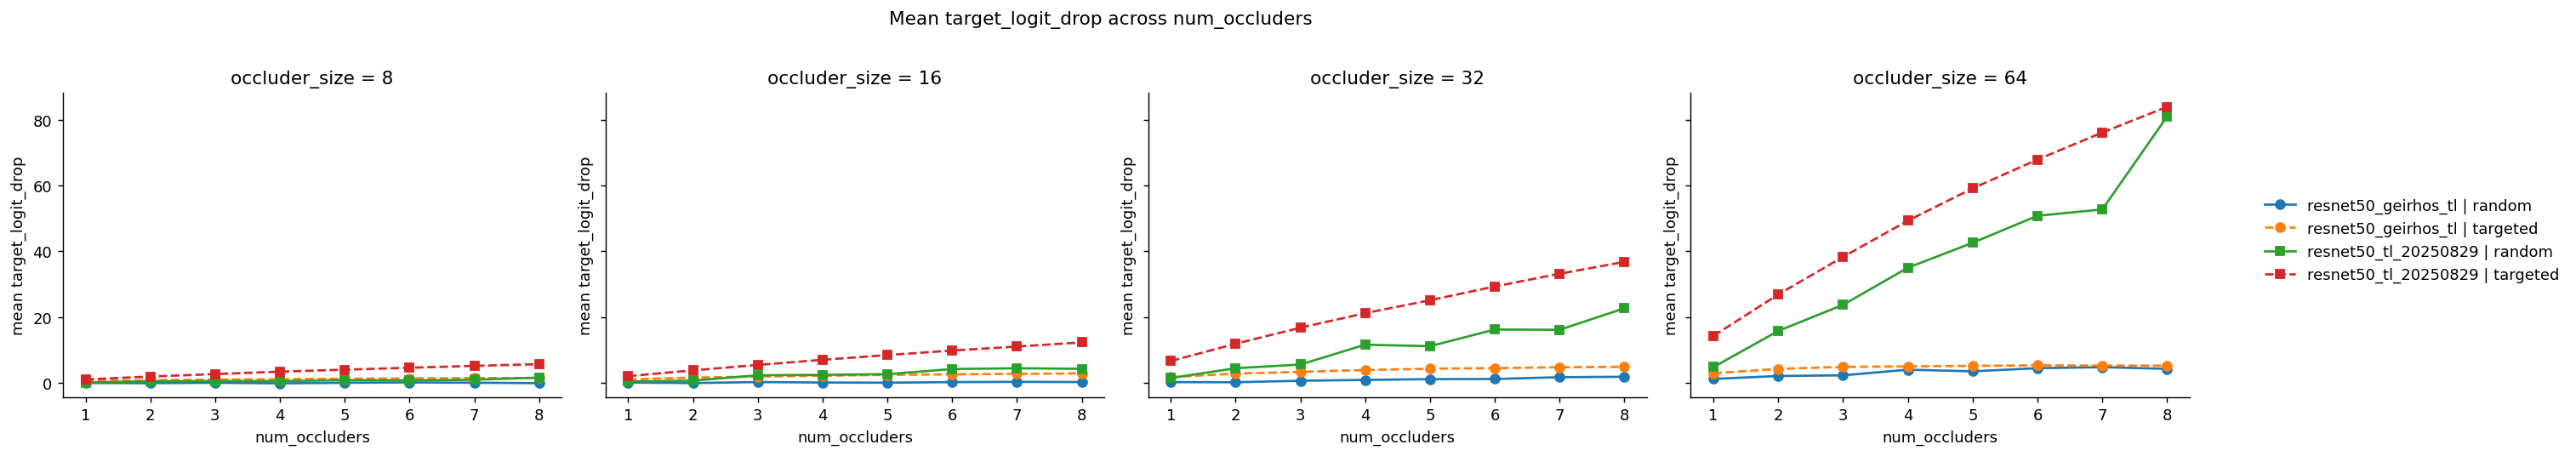

In [12]:
# Plot 1. Mean target_logit_drop across num_occluders
# Separate lines for model_type, distinguish placement_type, facet by occluder_size

plot_df = (
    analysis_df
    .groupby(["occluder_size", "model_type", "placement_type", "num_occluders"], observed=True)["target_logit_drop"]
    .mean()
    .reset_index()
)

n_sizes = len(size_levels)
fig, axes = plt.subplots(1, n_sizes, figsize=(5 * n_sizes, 4), sharey=True)

if n_sizes == 1:
    axes = [axes]

for ax, size in zip(axes, size_levels):
    sub = plot_df[plot_df["occluder_size"] == size]
    for i, model in enumerate(model_levels):
        for j, placement in enumerate(placement_levels):
            s = sub[(sub["model_type"] == model) & (sub["placement_type"] == placement)].sort_values("num_occluders")
            if len(s) == 0:
                continue
            ax.plot(
                s["num_occluders"],
                s["target_logit_drop"],
                linestyle=line_styles[j % len(line_styles)],
                marker=marker_styles[i % len(marker_styles)],
                label=f"{model} | {placement}"
            )
    ax.set_title(f"occluder_size = {size}")
    ax.set_xlabel("num_occluders")
    ax.set_ylabel("mean target_logit_drop")

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle("Mean target_logit_drop across num_occluders", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "mean_logit_drop_by_num_occluders_faceted_by_occluder_size.png", bbox_inches="tight")
plt.show()

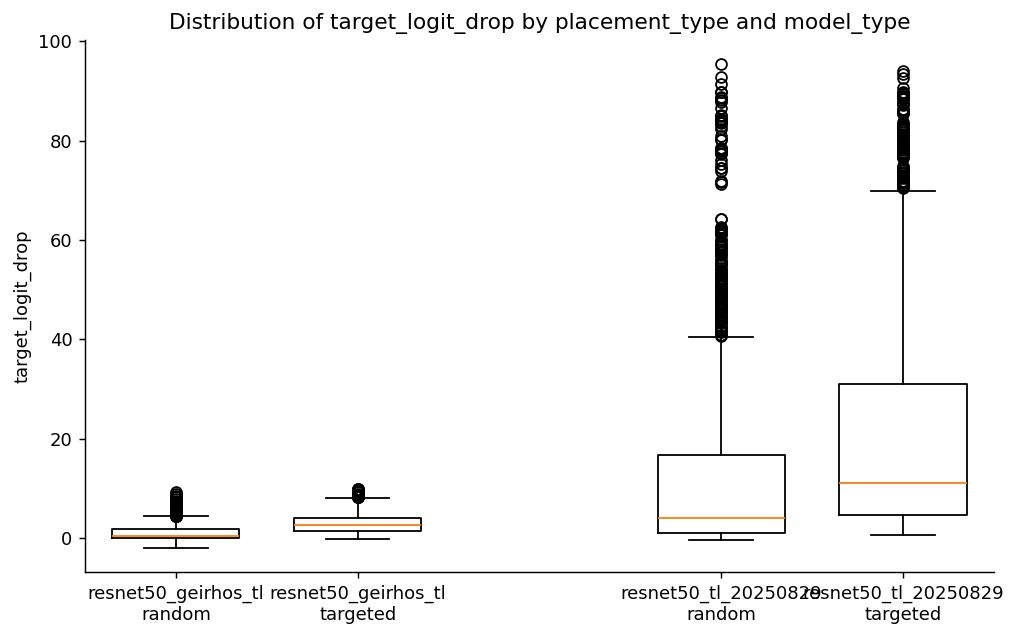

In [13]:
# Plot 2. Boxplot of target_logit_drop by placement_type, split by model_type

fig, ax = plt.subplots(figsize=(8, 5))

positions = []
data_to_plot = []
labels = []
pos = 1

for m in model_levels:
    for p in placement_levels:
        vals = analysis_df.loc[
            (analysis_df["model_type"] == m) & (analysis_df["placement_type"] == p),
            "target_logit_drop"
        ].dropna().values
        data_to_plot.append(vals)
        positions.append(pos)
        labels.append(f"{m}\n{p}")
        pos += 1
    pos += 1

ax.boxplot(data_to_plot, positions=positions, widths=0.7, patch_artist=False, showfliers=True)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("target_logit_drop")
ax.set_title("Distribution of target_logit_drop by placement_type and model_type")

fig.tight_layout()
fig.savefig(FIG_DIR / "boxplot_logit_drop_by_placement_and_model.png", bbox_inches="tight")
plt.show()

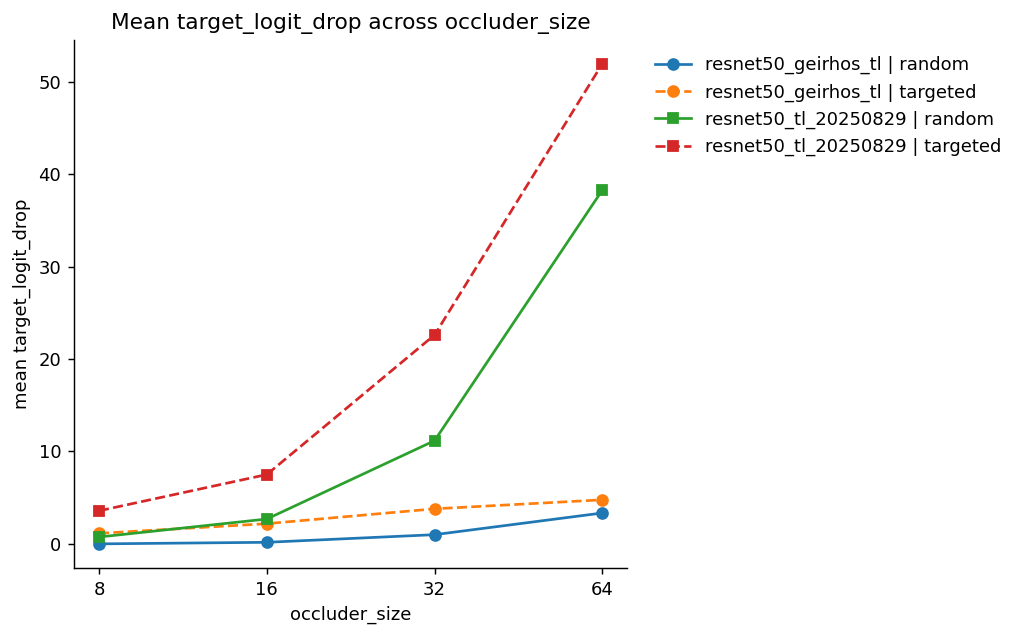

In [14]:
# Plot 3. Mean target_logit_drop across occluder_size, by model_type and placement_type

plot_df2 = (
    analysis_df
    .groupby(["occluder_size", "model_type", "placement_type"], observed=True)["target_logit_drop"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

x_positions = np.arange(len(size_levels))

for i, model in enumerate(model_levels):
    for j, placement in enumerate(placement_levels):
        s = plot_df2[(plot_df2["model_type"] == model) & (plot_df2["placement_type"] == placement)]
        s = s.set_index("occluder_size").reindex(size_levels).reset_index()
        ax.plot(
            x_positions,
            s["target_logit_drop"],
            linestyle=line_styles[j % len(line_styles)],
            marker=marker_styles[i % len(marker_styles)],
            label=f"{model} | {placement}"
        )

ax.set_xticks(x_positions)
ax.set_xticklabels([str(x) for x in size_levels])
ax.set_xlabel("occluder_size")
ax.set_ylabel("mean target_logit_drop")
ax.set_title("Mean target_logit_drop across occluder_size")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "mean_logit_drop_by_occluder_size.png", bbox_inches="tight")
plt.show()

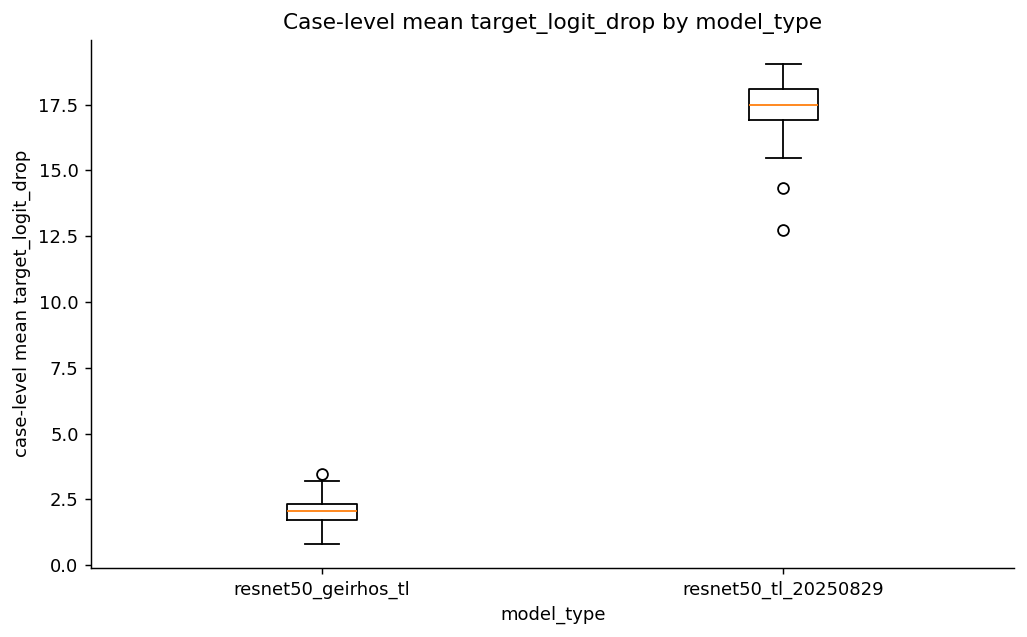

In [15]:
# Plot 4. Case-level mean target_logit_drop by model_type
# Useful for seeing spread across repeated cases without altering the main analysis

case_means = (
    analysis_df
    .groupby(["case_id", "model_type"], observed=True)["target_logit_drop"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [
    case_means.loc[case_means["model_type"] == m, "target_logit_drop"].dropna().values
    for m in model_levels
]

ax.boxplot(data_to_plot, labels=[str(m) for m in model_levels], patch_artist=False, showfliers=True)
ax.set_xlabel("model_type")
ax.set_ylabel("case-level mean target_logit_drop")
ax.set_title("Case-level mean target_logit_drop by model_type")

fig.tight_layout()
fig.savefig(FIG_DIR / "case_level_mean_logit_drop_by_model_type.png", bbox_inches="tight")
plt.show()

## Primary confirmatory analysis

### Preregistered target model
The confirmatory model is:

`target_logit_drop ~ model_type * placement_type * num_occluders * occluder_size`

with a random intercept for `case_id`.

### Notes on estimation in Python
In Python, the closest standard implementation is a linear mixed-effects model using `statsmodels` with:
- fixed effects given by the full factorial formula above
- grouping variable `case_id` as a random intercept

Mixed models with high-order interactions can be numerically fragile.  
This notebook therefore:
1. first attempts the full preregistered model
2. tries several optimizers if needed
3. retains the closest successfully fitted model
4. records clearly what was fitted

In [16]:
# Build confirmatory model formula

formula_full = "target_logit_drop ~ model_type * placement_type * num_occluders * occluder_size"
print(formula_full)

target_logit_drop ~ model_type * placement_type * num_occluders * occluder_size


In [17]:
# Fit mixed model with random intercept for case_id
# Keep all rows with non-missing values on required model variables.
# No filtering based on correctness variables is performed.

model_vars = [
    "target_logit_drop",
    "model_type",
    "placement_type",
    "num_occluders",
    "occluder_size",
    "case_id",
]

model_df = analysis_df[model_vars].copy()

print("Rows entering model fit:", len(model_df))
print("Unique case_id entering model fit:", model_df["case_id"].nunique())

Rows entering model fit: 5120
Unique case_id entering model fit: 40


In [18]:
# Attempt fitting with multiple optimizers

fit_attempts = []
mixed_result = None
fitted_formula = formula_full

for method in ["lbfgs", "bfgs", "cg", "powell", "nm"]:
    try:
        md = smf.mixedlm(
            formula=fitted_formula,
            data=model_df,
            groups=model_df["case_id"],
            re_formula="1"
        )
        res = md.fit(method=method, reml=False, maxiter=2000, disp=False)
        fit_attempts.append((method, "success", res.converged, res.llf))
        mixed_result = res
        print(f"Success with optimizer: {method}")
        break
    except Exception as e:
        fit_attempts.append((method, "failed", None, str(e)))
        print(f"Failed with optimizer: {method}")
        print("  ", str(e)[:300])

fit_attempts_df = pd.DataFrame(fit_attempts, columns=["optimizer", "status", "converged", "info"])
display(fit_attempts_df)

fit_attempts_df.to_csv(MODEL_DIR / "mixed_model_fit_attempts.csv", index=False)

Failed with optimizer: lbfgs
   Singular matrix
Success with optimizer: bfgs


,optimizer,status,converged,info
0,lbfgs,failed,None,Singular matrix
1,bfgs,success,True,-12084.263856


In [19]:
# Inspect fitted model

if mixed_result is None:
    raise RuntimeError(
        "Neither the full nor fallback mixed model could be fitted successfully. "
        "Inspect the fit attempts table and consider simplifying the fixed-effect structure."
    )

print("Fitted formula:")
print(fitted_formula)
print("\nConverged:", mixed_result.converged)
print("\nModel summary:")
print(mixed_result.summary())

Fitted formula:
target_logit_drop ~ model_type * placement_type * num_occluders * occluder_size

Converged: True

Model summary:
                                                  Mixed Linear Model Regression Results
Model:                                     MixedLM                          Dependent Variable:                          target_logit_drop
No. Observations:                          5120                             Method:                                      ML               
No. Groups:                                40                               Scale:                                       6.4510           
Min. group size:                           128                              Log-Likelihood:                              -12084.2639      
Max. group size:                           128                              Converged:                                   Yes              
Mean group size:                           128.0                                        

In [20]:
# Save model summary text

model_summary_text = mixed_result.summary().as_text()

with open(MODEL_DIR / "mixed_model_summary.txt", "w") as f:
    f.write("Fitted formula:\n")
    f.write(fitted_formula + "\n\n")
    f.write(model_summary_text)

print(model_summary_text)

                                                  Mixed Linear Model Regression Results
Model:                                     MixedLM                          Dependent Variable:                          target_logit_drop
No. Observations:                          5120                             Method:                                      ML               
No. Groups:                                40                               Scale:                                       6.4510           
Min. group size:                           128                              Log-Likelihood:                              -12084.2639      
Max. group size:                           128                              Converged:                                   Yes              
Mean group size:                           128.0                                                                                          
------------------------------------------------------------------------------

In [21]:
# Save model summary text

model_summary_text = mixed_result.summary().as_text()

with open(MODEL_DIR / "mixed_model_summary.txt", "w") as f:
    f.write("Fitted formula:\n")
    f.write(fitted_formula + "\n\n")
    f.write(model_summary_text)

print(model_summary_text)

                                                  Mixed Linear Model Regression Results
Model:                                     MixedLM                          Dependent Variable:                          target_logit_drop
No. Observations:                          5120                             Method:                                      ML               
No. Groups:                                40                               Scale:                                       6.4510           
Min. group size:                           128                              Log-Likelihood:                              -12084.2639      
Max. group size:                           128                              Converged:                                   Yes              
Mean group size:                           128.0                                                                                          
------------------------------------------------------------------------------

In [22]:
from scipy.stats import norm

fe_params = mixed_result.fe_params
fe_se = mixed_result.bse_fe
fe_z = fe_params / fe_se
fe_p = 2 * (1 - norm.cdf(np.abs(fe_z)))

fixed_effects_table = pd.DataFrame({
    "term": fe_params.index,
    "estimate": fe_params.values,
    "std_error": fe_se.values,
    "z_value": fe_z.values,
    "p_value": fe_p,
})

display(fixed_effects_table.sort_values("p_value"))

fixed_effects_table.to_csv(MODEL_DIR / "mixed_model_fixed_effects_table.csv", index=False)

,term,estimate,std_error,z_value,p_value
15,model_type[T.resnet50_tl_20250829]:placement_t...,9.866527,0.885064,11.147815,0.000000e+00
9,model_type[T.resnet50_tl_20250829]:occluder_si...,-6.098589,0.625835,-9.744729,0.000000e+00
24,model_type[T.resnet50_tl_20250829]:num_occlude...,2.437764,0.123934,19.669904,0.000000e+00
25,model_type[T.resnet50_tl_20250829]:num_occlude...,8.958907,0.123934,72.287890,0.000000e+00
21,num_occluders:occluder_size[T.64],0.477830,0.087634,5.452536,4.965664e-08
30,model_type[T.resnet50_tl_20250829]:placement_t...,0.891227,0.175269,5.084918,3.677856e-07
23,model_type[T.resnet50_tl_20250829]:num_occlude...,0.430339,0.123934,3.472332,5.159569e-04
14,model_type[T.resnet50_tl_20250829]:placement_t...,2.940596,0.885064,3.322468,8.922490e-04
22,model_type[T.resnet50_tl_20250829]:placement_t...,0.370879,0.123934,2.992560,2.766480e-03
12,placement_type[T.targeted]:occluder_size[T.64],1.824029,0.625835,2.914555,3.561957e-03


## Interpretation guide for key terms

Use the fixed-effects table together with the coding of categorical predictors.

### Main terms
- **`model_type`**  
  Tests whether models differ in average `target_logit_drop`, conditional on the reference levels and any included interactions.

- **`placement_type`**  
  Tests whether targeted versus other placement conditions differ in average `target_logit_drop`, conditional on the reference levels and any included interactions.

- **`num_occluders`**  
  Tests whether increasing the number of occluders is associated with a change in `target_logit_drop`, at the reference levels of the categorical predictors.

- **`occluder_size`**  
  Tests whether `target_logit_drop` differs across occluder sizes, conditional on the reference levels and any included interactions.

### Interaction terms
- **`model_type × placement_type`**  
  Tests whether the effect of placement differs between models.

- **`model_type × num_occluders`**  
  Tests whether the slope across occluder count differs by model.

- **`placement_type × num_occluders`**  
  Tests whether the slope across occluder count differs by placement condition.

- **`model_type × placement_type × num_occluders`**  
  This is especially important for the preregistered question of whether targeted occlusion affects models differently as occluder count increases.

- **Terms involving `occluder_size`**  
  These indicate whether model differences, placement differences, or occluder-count effects vary across occluder sizes.

### Practical reading rule
For the main preregistered hypothesis, inspect first:
1. the `model_type × placement_type × num_occluders` interaction
2. then the corresponding predicted means or simple slopes within occluder-size levels
3. then follow-up contrasts that compare:
   - model types within each placement condition
   - targeted versus random within each model type

## Model-based follow-up contrasts

Python does not yet have a single universally convenient equivalent of the full R-style estimated marginal means workflow for mixed models.  
A principled approach is still possible:

1. construct a reference grid over combinations of predictors
2. use the fitted fixed effects to obtain model-based predictions
3. compute pairwise contrasts from the fixed-effect covariance matrix
4. apply multiplicity correction across the contrast family

Below, the notebook provides:
- estimated marginal predictions on a balanced grid
- pairwise contrasts for:
  - model types within each placement condition
  - placement types within each model type
- Holm correction for multiplicity

In [23]:
# Build a reference grid for model-based predictions
# For num_occluders, predictions are computed at observed unique values.

grid = pd.DataFrame(
    list(itertools.product(
        model_levels,
        placement_levels,
        sorted(model_df["num_occluders"].dropna().unique()),
        size_levels
    )),
    columns=["model_type", "placement_type", "num_occluders", "occluder_size"]
)

grid["model_type"] = pd.Categorical(grid["model_type"], categories=model_levels)
grid["placement_type"] = pd.Categorical(grid["placement_type"], categories=placement_levels)
grid["occluder_size"] = pd.Categorical(grid["occluder_size"], categories=size_levels)

grid.head()

,model_type,placement_type,num_occluders,occluder_size
0,resnet50_geirhos_tl,random,1,8
1,resnet50_geirhos_tl,random,1,16
2,resnet50_geirhos_tl,random,1,32
3,resnet50_geirhos_tl,random,1,64
4,resnet50_geirhos_tl,random,2,8


In [24]:
# Generate fixed-effect design matrix for the grid
# Then compute predicted means and standard errors from the fixed effects only.

design_info = mixed_result.model.data.design_info
X_grid = dmatrix(design_info, grid, return_type="dataframe")

beta = mixed_result.fe_params.values
cov_beta = mixed_result.cov_params().loc[mixed_result.fe_params.index, mixed_result.fe_params.index].values

grid["predicted"] = X_grid.values @ beta
grid["predicted_se"] = np.sqrt(np.sum((X_grid.values @ cov_beta) * X_grid.values, axis=1))
grid["ci_lower"] = grid["predicted"] - 1.96 * grid["predicted_se"]
grid["ci_upper"] = grid["predicted"] + 1.96 * grid["predicted_se"]

display(grid.head(20))
grid.to_csv(TABLE_DIR / "model_based_reference_grid_predictions.csv", index=False)

,model_type,placement_type,num_occluders,occluder_size,predicted,predicted_se,ci_lower,ci_upper
0,resnet50_geirhos_tl,random,1,8,-0.036696,0.281159,-0.587768,0.514376
1,resnet50_geirhos_tl,random,1,16,0.049463,0.281159,-0.501609,0.600536
2,resnet50_geirhos_tl,random,1,32,0.125344,0.281159,-0.425728,0.676417
3,resnet50_geirhos_tl,random,1,64,1.633831,0.281159,1.082758,2.184903
4,resnet50_geirhos_tl,random,2,8,-0.026857,0.236667,-0.490724,0.437011
5,resnet50_geirhos_tl,random,2,16,0.083223,0.236667,-0.380644,0.547090
6,resnet50_geirhos_tl,random,2,32,0.373531,0.236667,-0.090336,0.837398
7,resnet50_geirhos_tl,random,2,64,2.121500,0.236667,1.657632,2.585367
8,resnet50_geirhos_tl,random,3,8,-0.017017,0.201623,-0.412198,0.378163
9,resnet50_geirhos_tl,random,3,16,0.116983,0.201623,-0.278198,0.512163


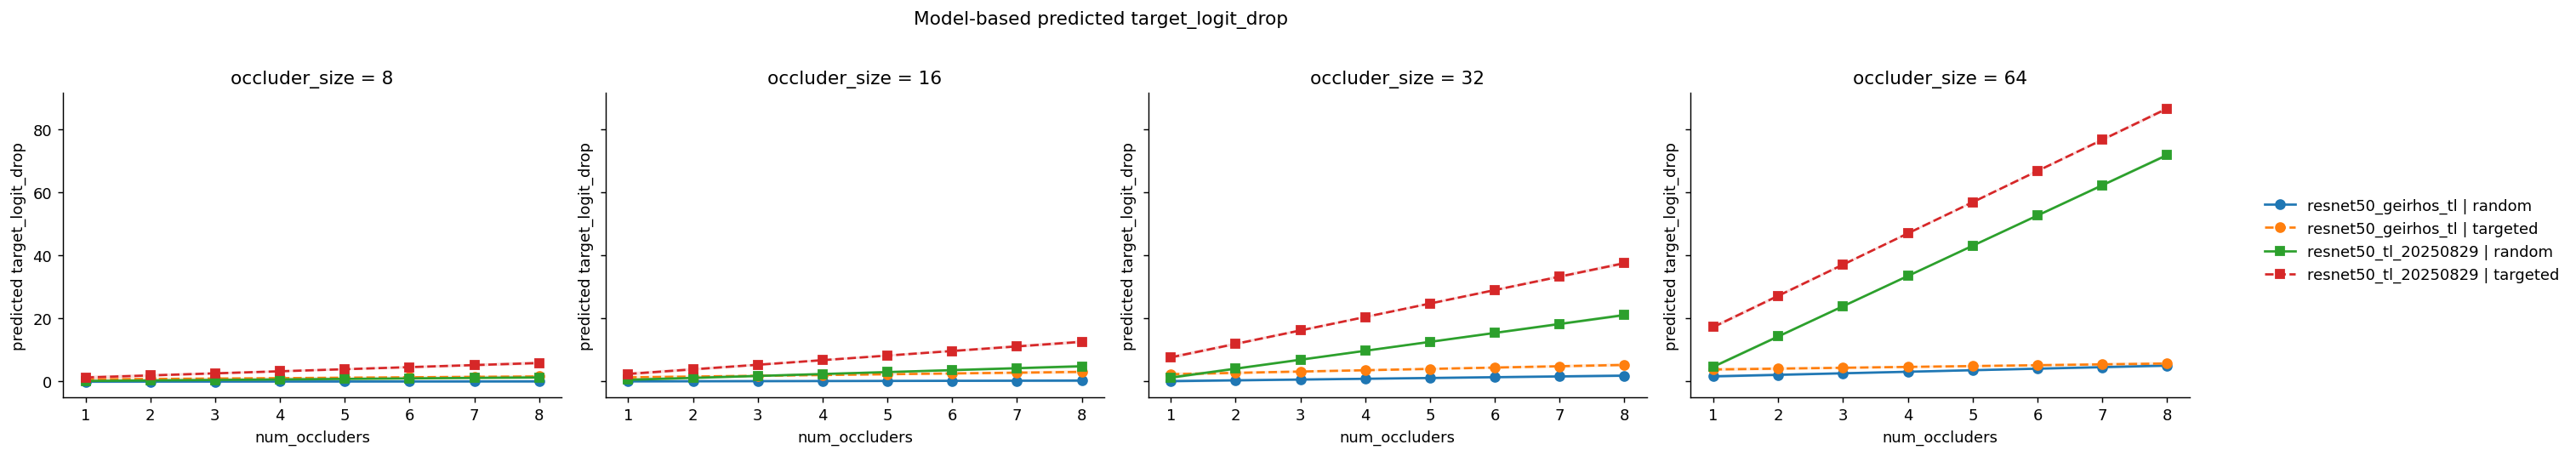

In [25]:
# Plot model-based predictions for the core confirmatory pattern:
# predicted target_logit_drop across num_occluders
# separate lines for model_type, line style by placement_type, facet by occluder_size

n_sizes = len(size_levels)
fig, axes = plt.subplots(1, n_sizes, figsize=(5 * n_sizes, 4), sharey=True)

if n_sizes == 1:
    axes = [axes]

for ax, size in zip(axes, size_levels):
    sub = grid[grid["occluder_size"] == size]
    for i, model in enumerate(model_levels):
        for j, placement in enumerate(placement_levels):
            s = sub[(sub["model_type"] == model) & (sub["placement_type"] == placement)].sort_values("num_occluders")
            ax.plot(
                s["num_occluders"],
                s["predicted"],
                linestyle=line_styles[j % len(line_styles)],
                marker=marker_styles[i % len(marker_styles)],
                label=f"{model} | {placement}"
            )
            ax.fill_between(
                s["num_occluders"].astype(float),
                s["ci_lower"].astype(float),
                s["ci_upper"].astype(float),
                alpha=0.15
            )
    ax.set_title(f"occluder_size = {size}")
    ax.set_xlabel("num_occluders")
    ax.set_ylabel("predicted target_logit_drop")

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle("Model-based predicted target_logit_drop", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_based_predictions_core_pattern.png", bbox_inches="tight")
plt.show()

In [26]:
# Contrast helper functions
from scipy.stats import norm

def contrast_from_rows(x1, x2, beta, cov_beta):
    """
    Compute contrast of two design rows: x1 - x2.
    Returns estimate, SE, z, p.
    """
    c = np.asarray(x1) - np.asarray(x2)
    est = c @ beta
    se = np.sqrt(c @ cov_beta @ c)
    z = est / se if se > 0 else np.nan
    p = 2 * (1 - norm.cdf(np.abs(z))) if np.isfinite(z) else np.nan
    return est, se, z, p


def holm_correct(df, p_col="p_value"):
    df = df.copy()
    mask = df[p_col].notna()
    corrected = multipletests(df.loc[mask, p_col], method="holm")
    df.loc[mask, "p_value_holm"] = corrected[1]
    df.loc[mask, "reject_holm"] = corrected[0]
    return df

In [27]:
# Follow-up contrasts A:
# Compare model types within each placement condition, num_occluders, and occluder_size.

contrast_rows = []

if len(model_levels) >= 2:
    model_pairs = list(itertools.combinations(model_levels, 2))
else:
    model_pairs = []

for placement in placement_levels:
    for n_occ in sorted(model_df["num_occluders"].dropna().unique()):
        for size in size_levels:
            for m1, m2 in model_pairs:
                row1 = pd.DataFrame({
                    "model_type": [m1],
                    "placement_type": [placement],
                    "num_occluders": [n_occ],
                    "occluder_size": [size],
                })
                row2 = pd.DataFrame({
                    "model_type": [m2],
                    "placement_type": [placement],
                    "num_occluders": [n_occ],
                    "occluder_size": [size],
                })

                row1["model_type"] = pd.Categorical(row1["model_type"], categories=model_levels)
                row1["placement_type"] = pd.Categorical(row1["placement_type"], categories=placement_levels)
                row1["occluder_size"] = pd.Categorical(row1["occluder_size"], categories=size_levels)

                row2["model_type"] = pd.Categorical(row2["model_type"], categories=model_levels)
                row2["placement_type"] = pd.Categorical(row2["placement_type"], categories=placement_levels)
                row2["occluder_size"] = pd.Categorical(row2["occluder_size"], categories=size_levels)

                x1 = dmatrix(design_info, row1, return_type="dataframe").values[0]
                x2 = dmatrix(design_info, row2, return_type="dataframe").values[0]

                est, se, z, p = contrast_from_rows(x1, x2, beta, cov_beta)

                contrast_rows.append({
                    "contrast_family": "model_within_placement",
                    "placement_type": placement,
                    "num_occluders": n_occ,
                    "occluder_size": size,
                    "level_1": m1,
                    "level_2": m2,
                    "estimate_diff": est,
                    "std_error": se,
                    "z_value": z,
                    "p_value": p,
                })

contrasts_model_within_placement = pd.DataFrame(contrast_rows)
contrasts_model_within_placement = holm_correct(contrasts_model_within_placement)

display(contrasts_model_within_placement.head(20))
contrasts_model_within_placement.to_csv(TABLE_DIR / "contrasts_model_within_placement.csv", index=False)

,contrast_family,placement_type,num_occluders,occluder_size,level_1,level_2,estimate_diff,std_error,z_value,p_value,p_value_holm,reject_holm
0,model_within_placement,random,1,8,resnet50_geirhos_tl,resnet50_tl_20250829,-0.213655,0.366601,-0.582799,5.600284e-01,5.600284e-01,False
1,model_within_placement,random,1,16,resnet50_geirhos_tl,resnet50_tl_20250829,-0.485043,0.366601,-1.323083,1.858079e-01,5.574237e-01,False
2,model_within_placement,random,1,32,resnet50_geirhos_tl,resnet50_tl_20250829,-1.116036,0.366601,-3.044280,2.332382e-03,1.632667e-02,True
3,model_within_placement,random,1,64,resnet50_geirhos_tl,resnet50_tl_20250829,-3.073973,0.366601,-8.385067,0.000000e+00,0.000000e+00,True
4,model_within_placement,random,2,8,resnet50_geirhos_tl,resnet50_tl_20250829,-0.364876,0.297183,-1.227785,2.195277e-01,5.574237e-01,False
5,model_within_placement,random,2,16,resnet50_geirhos_tl,resnet50_tl_20250829,-1.066604,0.297183,-3.589052,3.318822e-04,3.318822e-03,True
6,model_within_placement,random,2,32,resnet50_geirhos_tl,resnet50_tl_20250829,-3.705021,0.297183,-12.467154,0.000000e+00,0.000000e+00,True
7,model_within_placement,random,2,64,resnet50_geirhos_tl,resnet50_tl_20250829,-12.184101,0.297183,-40.998702,0.000000e+00,0.000000e+00,True
8,model_within_placement,random,3,8,resnet50_geirhos_tl,resnet50_tl_20250829,-0.516098,0.239997,-2.150439,3.152052e-02,1.576026e-01,False
9,model_within_placement,random,3,16,resnet50_geirhos_tl,resnet50_tl_20250829,-1.648165,0.239997,-6.867450,6.535883e-12,9.803824e-11,True


In [28]:
# Follow-up contrasts B:
# Compare placement types within each model type, num_occluders, and occluder_size.

contrast_rows = []

if len(placement_levels) >= 2:
    placement_pairs = list(itertools.combinations(placement_levels, 2))
else:
    placement_pairs = []

for model in model_levels:
    for n_occ in sorted(model_df["num_occluders"].dropna().unique()):
        for size in size_levels:
            for p1, p2 in placement_pairs:
                row1 = pd.DataFrame({
                    "model_type": [model],
                    "placement_type": [p1],
                    "num_occluders": [n_occ],
                    "occluder_size": [size],
                })
                row2 = pd.DataFrame({
                    "model_type": [model],
                    "placement_type": [p2],
                    "num_occluders": [n_occ],
                    "occluder_size": [size],
                })

                row1["model_type"] = pd.Categorical(row1["model_type"], categories=model_levels)
                row1["placement_type"] = pd.Categorical(row1["placement_type"], categories=placement_levels)
                row1["occluder_size"] = pd.Categorical(row1["occluder_size"], categories=size_levels)

                row2["model_type"] = pd.Categorical(row2["model_type"], categories=model_levels)
                row2["placement_type"] = pd.Categorical(row2["placement_type"], categories=placement_levels)
                row2["occluder_size"] = pd.Categorical(row2["occluder_size"], categories=size_levels)

                x1 = dmatrix(design_info, row1, return_type="dataframe").values[0]
                x2 = dmatrix(design_info, row2, return_type="dataframe").values[0]

                est, se, z, p = contrast_from_rows(x1, x2, beta, cov_beta)

                contrast_rows.append({
                    "contrast_family": "placement_within_model",
                    "model_type": model,
                    "num_occluders": n_occ,
                    "occluder_size": size,
                    "level_1": p1,
                    "level_2": p2,
                    "estimate_diff": est,
                    "std_error": se,
                    "z_value": z,
                    "p_value": p,
                })

contrasts_placement_within_model = pd.DataFrame(contrast_rows)
contrasts_placement_within_model = holm_correct(contrasts_placement_within_model)

display(contrasts_placement_within_model.head(20))
contrasts_placement_within_model.to_csv(TABLE_DIR / "contrasts_placement_within_model.csv", index=False)

,contrast_family,model_type,num_occluders,occluder_size,level_1,level_2,estimate_diff,std_error,z_value,p_value,p_value_holm,reject_holm
0,placement_within_model,resnet50_geirhos_tl,1,8,random,targeted,-0.704185,0.366601,-1.920849,5.475080e-02,1.095016e-01,False
1,placement_within_model,resnet50_geirhos_tl,1,16,random,targeted,-1.270917,0.366601,-3.466758,5.267756e-04,3.160653e-03,True
2,placement_within_model,resnet50_geirhos_tl,1,32,random,targeted,-2.196310,0.366601,-5.991010,2.085415e-09,3.753747e-08,True
3,placement_within_model,resnet50_geirhos_tl,1,64,random,targeted,-2.186656,0.366601,-5.964678,2.451165e-09,4.166981e-08,True
4,placement_within_model,resnet50_geirhos_tl,2,8,random,targeted,-0.828629,0.297183,-2.788281,5.298850e-03,1.589655e-02,True
5,placement_within_model,resnet50_geirhos_tl,2,16,random,targeted,-1.484612,0.297183,-4.995623,5.864615e-07,6.451076e-06,True
6,placement_within_model,resnet50_geirhos_tl,2,32,random,targeted,-2.368740,0.297183,-7.970655,1.554312e-15,3.885781e-14,True
7,placement_within_model,resnet50_geirhos_tl,2,64,random,targeted,-1.969542,0.297183,-6.627380,3.416956e-11,6.833911e-10,True
8,placement_within_model,resnet50_geirhos_tl,3,8,random,targeted,-0.953073,0.239997,-3.971192,7.151380e-05,5.005966e-04,True
9,placement_within_model,resnet50_geirhos_tl,3,16,random,targeted,-1.698308,0.239997,-7.076383,1.479705e-12,3.107381e-11,True


## Notes on the follow-up contrasts

The contrast tables above are model-based comparisons derived from the fitted fixed effects and their covariance matrix.

### Suggested reading strategy
- For the question of whether targeted occlusion affects models differently as occluder count increases:
  1. inspect the `model_type × placement_type × num_occluders` interaction in the mixed model
  2. inspect the model-based prediction plot
  3. inspect the follow-up contrasts at each `num_occluders` and `occluder_size`

### Multiplicity correction
Where pairwise contrasts are performed, Holm correction is applied within the contrast table.

In [29]:
# Save a concise run manifest for reproducibility

run_manifest = {
    "data_path": str(DATA_PATH),
    "n_rows_loaded": int(len(df)),
    "n_rows_analysis_df": int(len(analysis_df)),
    "n_rows_model_df": int(len(model_df)),
    "n_unique_case_id": int(analysis_df["case_id"].nunique()),
    "fitted_formula": fitted_formula,
    "model_converged": bool(mixed_result.converged),
    "statsmodels_version": sm.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
}

with open(MODEL_DIR / "run_manifest.json", "w") as f:
    json.dump(run_manifest, f, indent=2)

display(pd.Series(run_manifest, name="value").to_frame())

,value
data_path,/home/hschatzle/data/storage-occ-v2/repos/mont...
n_rows_loaded,5120
n_rows_analysis_df,5120
n_rows_model_df,5120
n_unique_case_id,40
fitted_formula,target_logit_drop ~ model_type * placement_typ...
model_converged,True
statsmodels_version,0.14.6
pandas_version,2.3.3
numpy_version,1.26.4


## What to inspect before interpreting results

Before drawing substantive conclusions, inspect the following:

1. **Audit outputs**
   - Are the factor levels what you expected?
   - Are there unexpected duplicates or missing values?
   - Is `num_occluders` taking the expected values?

2. **Cell sizes**
   - Check whether some `model_type × placement_type × occluder_size × num_occluders` combinations are very sparse.

3. **Distribution of `target_logit_drop`**
   - Look for strong skew, extreme outliers, or heterogeneity across conditions.

4. **Model convergence**
   - Confirm that the mixed model converged.
   - If the fallback model was used, report that explicitly.

5. **Reference coding**
   - Interpret coefficients in light of the categorical reference levels used by the model.

6. **High-order interactions**
   - Do not interpret lower-order terms in isolation if higher-order interactions involving those terms are substantial.

7. **Model-based predictions**
   - Use the prediction plot and contrast tables to understand the direction and practical meaning of key interactions.

8. **Scope of inference**
   - This Part I notebook preserves all rows by design, including rows where baseline classification was incorrect.
   - Interpretation should therefore remain tied to the preregistered outcome definition rather than post hoc sample restriction.

## Secondary analysis. Shape-intersecting occluder sensitivity analysis

This section restricts position-level occlusion results to occluder placements that intersect the stimulus shape.

### Rationale
The whole-image occlusion sweep averages across all possible placements, including placements that do not overlap the shape at all.  
This secondary analysis focuses only on placements where the occluder rectangle intersects the shape.

### Interpretation
This analysis is complementary to, but distinct from, the preregistered whole-image analysis:
- whole-image analysis: all placements
- intersecting-only analysis: only placements overlapping the shape

In [30]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

In [31]:
# User-editable paths for position-level sweep analysis

POSITION_ROOT = Path("/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts")
CASE_ROOT = Path("/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/data/cases/occlusion")

# Change this if your sweep used a different resized image size
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224

INTERSECT_DIR = OUTPUT_DIR / "intersecting_occluders"
INTERSECT_TABLE_DIR = INTERSECT_DIR / "tables"
INTERSECT_FIG_DIR = INTERSECT_DIR / "figures"

for p in [INTERSECT_DIR, INTERSECT_TABLE_DIR, INTERSECT_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("POSITION_ROOT:", POSITION_ROOT)
print("CASE_ROOT:", CASE_ROOT)
print("IMAGE_WIDTH, IMAGE_HEIGHT:", IMAGE_WIDTH, IMAGE_HEIGHT)

POSITION_ROOT: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts
CASE_ROOT: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/data/cases/occlusion
IMAGE_WIDTH, IMAGE_HEIGHT: 224 224


In [32]:
def find_case_metadata_json(case_dir: Path):
    """
    Return the JSONL metadata file in case_dir/generated that contains shape_contour_xy.
    """
    generated_dir = case_dir / "generated"
    jsonl_files = sorted(generated_dir.glob("*.jsonl"))

    for fp in jsonl_files:
        try:
            with open(fp, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    obj = json.loads(line)
                    if "shape_contour_xy" in obj:
                        return fp
        except Exception:
            pass

    return None


def load_shape_contour(case_id: str):
    case_dir = CASE_ROOT / case_id
    meta_fp = find_case_metadata_json(case_dir)

    if meta_fp is None:
        raise FileNotFoundError(
            f"No JSONL metadata with shape_contour_xy found for case_id={case_id} in {case_dir / 'generated'}"
        )

    with open(meta_fp, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "shape_contour_xy" in obj:
                contour = np.asarray(obj["shape_contour_xy"], dtype=float)
                return contour, meta_fp

    raise ValueError(
        f"Found metadata file for case_id={case_id}, but no line contained shape_contour_xy: {meta_fp}"
    )

In [33]:
# Geometry helpers

def rect_from_position_row(row, image_width=224, image_height=224):
    """
    Convert x0, y0, occluder_size from image-grid units to normalized [0,1] rectangle corners.
    Assumes square occluders in the sweep.
    """
    x0 = float(row["x0"]) / image_width
    y0 = float(row["y0"]) / image_height
    x1 = (float(row["x0"]) + float(row["occluder_size"])) / image_width
    y1 = (float(row["y0"]) + float(row["occluder_size"])) / image_height

    rect = np.array([
        [x0, y0],
        [x1, y0],
        [x1, y1],
        [x0, y1],
    ], dtype=float)
    return rect


def point_in_rect(points, rect):
    """
    points: (N,2)
    rect: corners in axis-aligned order
    """
    x_min = np.min(rect[:, 0])
    x_max = np.max(rect[:, 0])
    y_min = np.min(rect[:, 1])
    y_max = np.max(rect[:, 1])

    inside = (
        (points[:, 0] >= x_min) &
        (points[:, 0] <= x_max) &
        (points[:, 1] >= y_min) &
        (points[:, 1] <= y_max)
    )
    return inside


def segments_from_poly(poly):
    """
    poly: (N,2), treated as closed polygon
    """
    segs = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i + 1) % n]
        segs.append((p1, p2))
    return segs


def ccw(A, B, C):
    return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])


def segments_intersect(A, B, C, D):
    return (ccw(A, C, D) != ccw(B, C, D)) and (ccw(A, B, C) != ccw(A, B, D))


def rect_edges(rect):
    return [
        (rect[0], rect[1]),
        (rect[1], rect[2]),
        (rect[2], rect[3]),
        (rect[3], rect[0]),
    ]


def point_on_rect_boundary(point, rect, tol=1e-9):
    x, y = float(point[0]), float(point[1])
    x_min = float(np.min(rect[:, 0]))
    x_max = float(np.max(rect[:, 0]))
    y_min = float(np.min(rect[:, 1]))
    y_max = float(np.max(rect[:, 1]))

    on_left   = abs(x - x_min) <= tol and (y_min - tol <= y <= y_max + tol)
    on_right  = abs(x - x_max) <= tol and (y_min - tol <= y <= y_max + tol)
    on_bottom = abs(y - y_min) <= tol and (x_min - tol <= x <= x_max + tol)
    on_top    = abs(y - y_max) <= tol and (x_min - tol <= x <= x_max + tol)

    return on_left or on_right or on_bottom or on_top


def orient(a, b, c):
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def on_segment(a, b, p, tol=1e-9):
    return (
        min(a[0], b[0]) - tol <= p[0] <= max(a[0], b[0]) + tol and
        min(a[1], b[1]) - tol <= p[1] <= max(a[1], b[1]) + tol and
        abs(orient(a, b, p)) <= tol
    )


def segments_intersect_inclusive(A, B, C, D, tol=1e-9):
    o1 = orient(A, B, C)
    o2 = orient(A, B, D)
    o3 = orient(C, D, A)
    o4 = orient(C, D, B)

    # Proper intersection
    if ((o1 > tol and o2 < -tol) or (o1 < -tol and o2 > tol)) and \
       ((o3 > tol and o4 < -tol) or (o3 < -tol and o4 > tol)):
        return True

    # Collinear / touching cases
    if abs(o1) <= tol and on_segment(A, B, C, tol):
        return True
    if abs(o2) <= tol and on_segment(A, B, D, tol):
        return True
    if abs(o3) <= tol and on_segment(C, D, A, tol):
        return True
    if abs(o4) <= tol and on_segment(C, D, B, tol):
        return True

    return False


def rect_intersects_contour(rect, contour, tol=1e-9):
    """
    True only if the rectangle intersects the contour path itself.
    Interior-only overlap does NOT count.
    """
    shape_segs = segments_from_poly(contour)
    rect_segs = rect_edges(rect)

    # 1. Any contour edge intersects or touches any rectangle edge
    for s1a, s1b in shape_segs:
        for s2a, s2b in rect_segs:
            if segments_intersect_inclusive(s1a, s1b, s2a, s2b, tol=tol):
                return True

    # 2. Any contour vertex lies exactly on rectangle boundary
    for p in contour:
        if point_on_rect_boundary(p, rect, tol=tol):
            return True

    return False

In [34]:
# Collect all position score files

position_files = sorted(POSITION_ROOT.glob("*/*/position_scores_size_*.csv"))

print("Number of position score files found:", len(position_files))
position_files[:5]

Number of position score files found: 320


[PosixPath('/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts/ns_cow_202/resnet50_geirhos_tl/position_scores_size_16.csv'),
 PosixPath('/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts/ns_cow_202/resnet50_geirhos_tl/position_scores_size_32.csv'),
 PosixPath('/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts/ns_cow_202/resnet50_geirhos_tl/position_scores_size_64.csv'),
 PosixPath('/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts/ns_cow_202/resnet50_geirhos_tl/position_scores_size_8.csv'),
 PosixPath('/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part1_occlusion_robustness/artifacts/ns_cow_202/resnet50_tl_20250829/position_scores_size_16.csv')]

In [35]:
# Load all position score files into one dataframe

dfs = []

for fp in position_files:
    tmp = pd.read_csv(fp)

    # infer case_id and model_type from path if needed
    # expected structure:
    # ... / artifacts / {case_id} / {model_type} / position_scores_size_{size}.csv
    case_id_from_path = fp.parent.parent.name
    model_type_from_path = fp.parent.name

    if "case_id" not in tmp.columns:
        tmp["case_id"] = case_id_from_path
    if "model_type" not in tmp.columns:
        tmp["model_type"] = model_type_from_path

    tmp["source_file"] = str(fp)
    dfs.append(tmp)

position_df = pd.concat(dfs, ignore_index=True)

print("Combined position-level shape:", position_df.shape)
display(position_df.head())

Combined position-level shape: (316720, 12)


,case_id,model_type,occluder_size,stride,y0,x0,y_center,x_center,baseline_target_logit,post_occlusion_target_logit,target_logit_drop,source_file
0,ns_cow_202,resnet50_geirhos_tl,16,8,0,0,8.0,8.0,7.092349,6.896708,0.195641,/home/hschatzle/data/storage-occ-v2/repos/mont...
1,ns_cow_202,resnet50_geirhos_tl,16,8,0,8,8.0,16.0,7.092349,6.893960,0.198389,/home/hschatzle/data/storage-occ-v2/repos/mont...
2,ns_cow_202,resnet50_geirhos_tl,16,8,0,16,8.0,24.0,7.092349,6.804824,0.287524,/home/hschatzle/data/storage-occ-v2/repos/mont...
3,ns_cow_202,resnet50_geirhos_tl,16,8,0,24,8.0,32.0,7.092349,6.852989,0.239359,/home/hschatzle/data/storage-occ-v2/repos/mont...
4,ns_cow_202,resnet50_geirhos_tl,16,8,0,32,8.0,40.0,7.092349,6.827786,0.264562,/home/hschatzle/data/storage-occ-v2/repos/mont...


In [36]:
# Basic audit of position-level dataframe

print("Columns:")
print(list(position_df.columns))

print("\nMissing values:")
display(position_df.isna().sum().to_frame("n_missing"))

print("\nUnique case_id:", position_df["case_id"].nunique())
print("Unique model_type:", position_df["model_type"].nunique())
print("Unique occluder_size:", sorted(position_df["occluder_size"].dropna().unique().tolist()))

Columns:
['case_id', 'model_type', 'occluder_size', 'stride', 'y0', 'x0', 'y_center', 'x_center', 'baseline_target_logit', 'post_occlusion_target_logit', 'target_logit_drop', 'source_file']

Missing values:


,n_missing
case_id,0
model_type,0
occluder_size,0
stride,0
y0,0
x0,0
y_center,0
x_center,0
baseline_target_logit,0
post_occlusion_target_logit,0



Unique case_id: 40
Unique model_type: 2
Unique occluder_size: [8, 16, 32, 64]


In [37]:
# Cache shape contours once per case_id

shape_cache = {}
meta_cache = {}

for case_id in sorted(position_df["case_id"].dropna().unique()):
    contour, meta_fp = load_shape_contour(case_id)
    shape_cache[case_id] = contour
    meta_cache[case_id] = str(meta_fp)

print("Loaded contours for", len(shape_cache), "cases")

Loaded contours for 40 cases


In [38]:
def rect_from_xy_size(x0, y0, size, image_width=224, image_height=224):
    x0n = float(x0) / image_width
    y0n = float(y0) / image_height
    x1n = (float(x0) + float(size)) / image_width
    y1n = (float(y0) + float(size)) / image_height

    return np.array([
        [x0n, y0n],
        [x1n, y0n],
        [x1n, y1n],
        [x0n, y1n],
    ], dtype=float)

def compute_intersection_flags_for_chunk(chunk_df, shape_cache_dict, image_width=224, image_height=224):
    chunk_df = chunk_df.copy()

    flags = []
    for row in chunk_df.itertuples(index=False):
        contour = shape_cache_dict[row.case_id]
        rect = rect_from_xy_size(
            row.x0, row.y0, row.occluder_size,
            image_width=image_width,
            image_height=image_height,
        )
        flags.append(int(rect_intersects_shape(rect, contour)))

    chunk_df["intersects_shape"] = flags
    return chunk_df

In [39]:
# Parallel intersection computation across case-level chunks

from concurrent.futures import ProcessPoolExecutor
import os

N_CORES = 60  # set to the number of cores you want to use


def compute_intersection_flags_for_chunk(chunk_df, shape_cache_dict, image_width=224, image_height=224):
    """
    Compute intersects_shape for one dataframe chunk.
    Expects chunk_df to contain one or more case_ids.
    """
    chunk_df = chunk_df.copy()

    flags = []
    for row in chunk_df.itertuples(index=False):
        contour = shape_cache_dict[row.case_id]
        rect = rect_from_position_row(
            {
                "x0": row.x0,
                "y0": row.y0,
                "occluder_size": row.occluder_size,
            },
            image_width=image_width,
            image_height=image_height,
        )
        flag = rect_intersects_contour(rect, contour)
        flags.append(int(flag))

    chunk_df["intersects_shape"] = flags
    return chunk_df


# Split by case_id so each worker handles larger chunks
case_ids = sorted(position_df["case_id"].dropna().unique().tolist())
case_chunks = [position_df[position_df["case_id"] == cid].copy() for cid in case_ids]

print(f"Number of case-level chunks: {len(case_chunks)}")
print(f"Using {N_CORES} workers")

with ProcessPoolExecutor(max_workers=N_CORES) as ex:
    results = list(
        ex.map(
            compute_intersection_flags_for_chunk,
            case_chunks,
            [shape_cache] * len(case_chunks),
            [IMAGE_WIDTH] * len(case_chunks),
            [IMAGE_HEIGHT] * len(case_chunks),
        )
    )

position_df_parallel = pd.concat(results, ignore_index=True)

display(
    position_df_parallel[
        ["case_id", "model_type", "occluder_size", "x0", "y0", "intersects_shape"]
    ].head(20)
)

Number of case-level chunks: 40
Using 60 workers


Process ForkProcess-57:
Process ForkProcess-59:
Process ForkProcess-53:
Process ForkProcess-49:
Process ForkProcess-58:
Process ForkProcess-48:
Process ForkProcess-60:
Process ForkProcess-52:
Process ForkProcess-54:
Process ForkProcess-56:
Process ForkProcess-46:
Process ForkProcess-50:
Process ForkProcess-43:
Process ForkProcess-55:
Process ForkProcess-41:
Process ForkProcess-51:
Process ForkProcess-44:
Process ForkProcess-42:
Process ForkProcess-47:
Process ForkProcess-45:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314

KeyboardInterrupt: 

In [ ]:
position_df = position_df_parallel.copy()

In [ ]:
# Save the annotated position-level dataframe

position_df.to_csv(INTERSECT_TABLE_DIR / "position_scores_with_intersection_flag.csv", index=False)

intersection_audit = (
    position_df
    .groupby(["model_type", "occluder_size"], observed=True)
    .agg(
        n_positions=("intersects_shape", "size"),
        n_intersecting=("intersects_shape", "sum"),
        prop_intersecting=("intersects_shape", "mean"),
    )
    .reset_index()
)

display(intersection_audit)
intersection_audit.to_csv(INTERSECT_TABLE_DIR / "intersection_audit_by_model_and_size.csv", index=False)

,model_type,occluder_size,n_positions,n_intersecting,prop_intersecting
0,resnet50_geirhos_tl,8,121000,19291,0.159430
1,resnet50_geirhos_tl,16,29160,8674,0.297462
2,resnet50_geirhos_tl,32,6760,3535,0.522929
3,resnet50_geirhos_tl,64,1440,1178,0.818056
4,resnet50_tl_20250829,8,121000,19291,0.159430
5,resnet50_tl_20250829,16,29160,8674,0.297462
6,resnet50_tl_20250829,32,6760,3535,0.522929
7,resnet50_tl_20250829,64,1440,1178,0.818056


## Restrict to intersecting occluders

The following summaries and plots use only occluder positions for which `intersects_shape == 1`.

In [ ]:
intersect_df = position_df[position_df["intersects_shape"] == 1].copy()

print("All positions:", len(position_df))
print("Intersecting positions:", len(intersect_df))
print("Proportion intersecting:", len(intersect_df) / len(position_df))

All positions: 316720
Intersecting positions: 65356
Proportion intersecting: 0.20635261429653953


In [ ]:
# Overall descriptives for intersecting-only rows

intersect_overall = pd.DataFrame({
    "n": [intersect_df["target_logit_drop"].notna().sum()],
    "mean": [intersect_df["target_logit_drop"].mean()],
    "sd": [intersect_df["target_logit_drop"].std()],
    "median": [intersect_df["target_logit_drop"].median()],
    "min": [intersect_df["target_logit_drop"].min()],
    "max": [intersect_df["target_logit_drop"].max()],
})

display(intersect_overall)
intersect_overall.to_csv(INTERSECT_TABLE_DIR / "intersecting_only_desc_overall.csv", index=False)

,n,mean,sd,median,min,max
0,65356,0.42861,1.309792,0.120728,-2.131067,16.553062


In [ ]:
# Grouped summaries for intersecting-only rows

intersect_by_model = (
    intersect_df
    .groupby(["model_type"], observed=True)["target_logit_drop"]
    .agg(n="count", mean="mean", sd="std", median="median", min="min", max="max")
    .reset_index()
)

intersect_by_size = (
    intersect_df
    .groupby(["occluder_size"], observed=True)["target_logit_drop"]
    .agg(n="count", mean="mean", sd="std", median="median", min="min", max="max")
    .reset_index()
)

intersect_by_model_size = (
    intersect_df
    .groupby(["model_type", "occluder_size"], observed=True)["target_logit_drop"]
    .agg(n="count", mean="mean", sd="std", median="median", min="min", max="max")
    .reset_index()
)

display(intersect_by_model)
display(intersect_by_size)
display(intersect_by_model_size)

intersect_by_model.to_csv(INTERSECT_TABLE_DIR / "intersecting_only_desc_by_model.csv", index=False)
intersect_by_size.to_csv(INTERSECT_TABLE_DIR / "intersecting_only_desc_by_size.csv", index=False)
intersect_by_model_size.to_csv(INTERSECT_TABLE_DIR / "intersecting_only_desc_by_model_x_size.csv", index=False)

,model_type,n,mean,sd,median,min,max
0,resnet50_geirhos_tl,32678,0.067911,0.366059,0.028237,-2.131067,4.794725
1,resnet50_tl_20250829,32678,0.789309,1.742684,0.249817,-1.758194,16.553062


,occluder_size,n,mean,sd,median,min,max
0,8,38582,0.094905,0.186128,0.078805,-0.966578,1.358337
1,16,17348,0.295347,0.466482,0.194187,-1.439797,2.784821
2,32,7070,1.325011,1.692458,0.701998,-1.815239,8.234756
3,64,2356,4.184680,4.284770,2.528571,-2.131067,16.553062


,model_type,occluder_size,n,mean,sd,median,min,max
0,resnet50_geirhos_tl,8,19291,0.009808,0.155471,0.014458,-0.966578,1.025191
1,resnet50_geirhos_tl,16,8674,0.035948,0.285000,0.036580,-1.439797,2.380950
2,resnet50_geirhos_tl,32,3535,0.194106,0.536181,0.143349,-1.815239,3.368940
3,resnet50_geirhos_tl,64,1178,0.876077,1.047835,0.685547,-2.131067,4.794725
4,resnet50_tl_20250829,8,19291,0.180002,0.175027,0.159508,-0.617218,1.358337
5,resnet50_tl_20250829,16,8674,0.554745,0.468423,0.483215,-0.944595,2.784821
6,resnet50_tl_20250829,32,3535,2.455916,1.698097,2.162506,-1.558945,8.234756
7,resnet50_tl_20250829,64,1178,7.493283,3.704569,7.240685,-1.758194,16.553062


In [40]:
# Plot. Mean target_logit_drop by occluder_size using only intersecting occluders

plot_df = (
    intersect_df
    .groupby(["model_type", "occluder_size"], observed=True)["target_logit_drop"]
    .mean()
    .reset_index()
)

model_levels_intersect = sorted(plot_df["model_type"].unique().tolist())
size_levels_intersect = sorted(plot_df["occluder_size"].unique().tolist())

fig, ax = plt.subplots(figsize=(8, 5))

x_positions = np.arange(len(size_levels_intersect))

for i, model in enumerate(model_levels_intersect):
    s = (
        plot_df[plot_df["model_type"] == model]
        .set_index("occluder_size")
        .reindex(size_levels_intersect)
        .reset_index()
    )
    ax.plot(
        x_positions,
        s["target_logit_drop"],
        marker="o",
        linestyle="-",
        label=str(model)
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([str(x) for x in size_levels_intersect])
ax.set_xlabel("occluder_size")
ax.set_ylabel("mean target_logit_drop")
ax.set_title("Mean target_logit_drop by occluder_size\nintersecting occluders only")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(INTERSECT_FIG_DIR / "mean_logit_drop_by_size_intersecting_only.png", bbox_inches="tight")
plt.show()

NameError: name 'intersect_df' is not defined

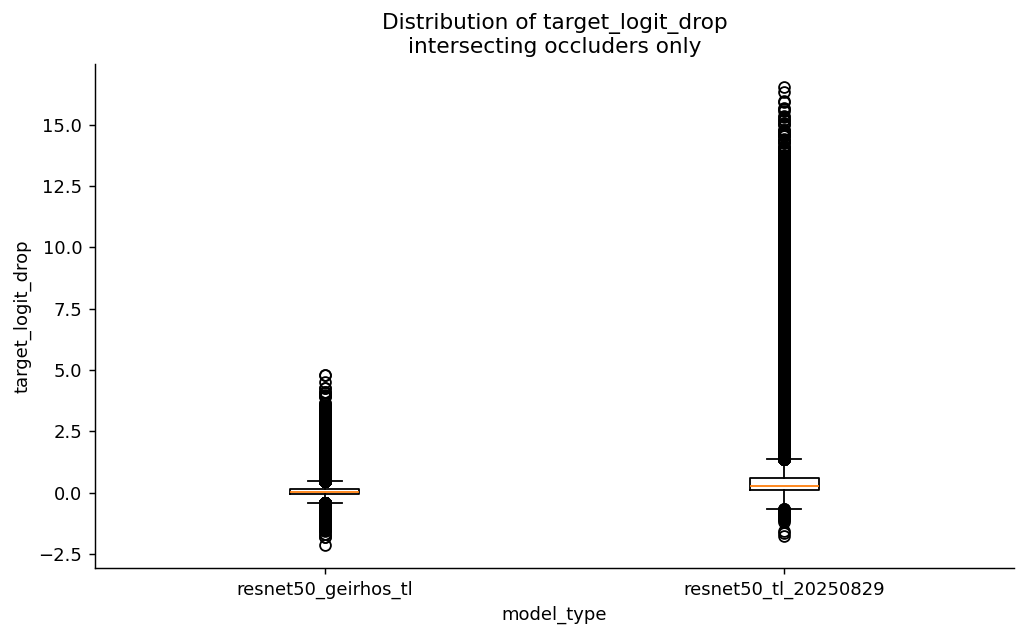

In [ ]:
# Plot. Boxplot by model_type using only intersecting occluders

fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [
    intersect_df.loc[intersect_df["model_type"] == m, "target_logit_drop"].dropna().values
    for m in model_levels_intersect
]

ax.boxplot(data_to_plot, labels=[str(m) for m in model_levels_intersect], showfliers=True)
ax.set_xlabel("model_type")
ax.set_ylabel("target_logit_drop")
ax.set_title("Distribution of target_logit_drop\nintersecting occluders only")

fig.tight_layout()
fig.savefig(INTERSECT_FIG_DIR / "boxplot_logit_drop_by_model_intersecting_only.png", bbox_inches="tight")
plt.show()

In [ ]:
# Optional comparison table: all positions vs intersecting-only positions

all_summary = (
    position_df
    .groupby(["model_type", "occluder_size"], observed=True)["target_logit_drop"]
    .agg(mean_all="mean", n_all="count")
    .reset_index()
)

inter_summary = (
    intersect_df
    .groupby(["model_type", "occluder_size"], observed=True)["target_logit_drop"]
    .agg(mean_intersecting="mean", n_intersecting="count")
    .reset_index()
)

compare_summary = all_summary.merge(
    inter_summary,
    on=["model_type", "occluder_size"],
    how="left"
)

compare_summary["mean_difference"] = compare_summary["mean_intersecting"] - compare_summary["mean_all"]

display(compare_summary)
compare_summary.to_csv(INTERSECT_TABLE_DIR / "compare_all_vs_intersecting_only.csv", index=False)

,model_type,occluder_size,mean_all,n_all,mean_intersecting,n_intersecting,mean_difference
0,resnet50_geirhos_tl,8,0.009861,121000,0.009808,19291,-0.000053
1,resnet50_geirhos_tl,16,0.036093,29160,0.035948,8674,-0.000144
2,resnet50_geirhos_tl,32,0.185347,6760,0.194106,3535,0.008758
3,resnet50_geirhos_tl,64,0.824550,1440,0.876077,1178,0.051527
4,resnet50_tl_20250829,8,0.170205,121000,0.180002,19291,0.009797
5,resnet50_tl_20250829,16,0.566149,29160,0.554745,8674,-0.011404
6,resnet50_tl_20250829,32,2.545960,6760,2.455916,3535,-0.090044
7,resnet50_tl_20250829,64,7.611295,1440,7.493283,1178,-0.118013


## What to inspect for this sensitivity analysis

Before interpreting the intersecting-only plots, inspect:

1. Whether the image-size assumption used to normalize `x0`, `y0`, and `occluder_size` is correct.
2. Whether `shape_contour_xy` defines a closed polygon consistent with the visible object region.
3. The proportion of placements classified as intersecting, by model and occluder size.
4. Whether filtering to intersecting placements changes the pattern mainly by:
   - shifting the mean upward
   - changing model differences
   - changing occluder-size trends
5. Whether conclusions from the intersecting-only analysis align with or diverge from the whole-image sweep.

In [ ]:
# Optional quick sanity check summary for coverage by case

intersection_by_case = (
    position_df
    .groupby(["case_id", "model_type", "occluder_size"], observed=True)
    .agg(
        n_positions=("intersects_shape", "size"),
        n_intersecting=("intersects_shape", "sum"),
        prop_intersecting=("intersects_shape", "mean"),
    )
    .reset_index()
)

display(intersection_by_case.head(20))
intersection_by_case.to_csv(INTERSECT_TABLE_DIR / "intersection_by_case.csv", index=False)

,case_id,model_type,occluder_size,n_positions,n_intersecting,prop_intersecting
0,ns_cow_202,resnet50_geirhos_tl,8,3025,512,0.169256
1,ns_cow_202,resnet50_geirhos_tl,16,729,212,0.290809
2,ns_cow_202,resnet50_geirhos_tl,32,169,82,0.485207
3,ns_cow_202,resnet50_geirhos_tl,64,36,29,0.805556
4,ns_cow_202,resnet50_tl_20250829,8,3025,512,0.169256
5,ns_cow_202,resnet50_tl_20250829,16,729,212,0.290809
6,ns_cow_202,resnet50_tl_20250829,32,169,82,0.485207
7,ns_cow_202,resnet50_tl_20250829,64,36,29,0.805556
8,ns_cow_205,resnet50_geirhos_tl,8,3025,510,0.168595
9,ns_cow_205,resnet50_geirhos_tl,16,729,237,0.325103


## Save the highest-impact intersecting occluder per shape, model, and size

This section identifies, for each `case_id × model_type × occluder_size` combination, the intersecting occluder position with the largest `target_logit_drop`.

Ties are broken deterministically by:
1. larger `target_logit_drop`
2. smaller `y0`
3. smaller `x0`

The resulting table is saved to disk.

In [ ]:
# Keep only intersecting occluders

best_intersect_df = position_df[position_df["intersects_shape"] == 1].copy()

print("Rows available for best-occluder selection:", len(best_intersect_df))
display(
    best_intersect_df[
        ["case_id", "model_type", "occluder_size", "x0", "y0", "target_logit_drop", "intersects_shape"]
    ].head(20)
)

Rows available for best-occluder selection: 65356


,case_id,model_type,occluder_size,x0,y0,target_logit_drop,intersects_shape
190,ns_cow_202,resnet50_geirhos_tl,16,8,56,0.303012,1
191,ns_cow_202,resnet50_geirhos_tl,16,16,56,-0.323071,1
192,ns_cow_202,resnet50_geirhos_tl,16,24,56,-0.375949,1
193,ns_cow_202,resnet50_geirhos_tl,16,32,56,-0.480918,1
194,ns_cow_202,resnet50_geirhos_tl,16,40,56,-0.372140,1
206,ns_cow_202,resnet50_geirhos_tl,16,136,56,-0.220111,1
207,ns_cow_202,resnet50_geirhos_tl,16,144,56,0.030015,1
208,ns_cow_202,resnet50_geirhos_tl,16,152,56,0.097391,1
212,ns_cow_202,resnet50_geirhos_tl,16,184,56,-0.006519,1
213,ns_cow_202,resnet50_geirhos_tl,16,192,56,0.038478,1


In [ ]:
# Add normalized rectangle coordinates for saving and later plotting

best_intersect_df = best_intersect_df.copy()

best_intersect_df["x0_norm"] = best_intersect_df["x0"] / IMAGE_WIDTH
best_intersect_df["y0_norm"] = best_intersect_df["y0"] / IMAGE_HEIGHT
best_intersect_df["x1_norm"] = (best_intersect_df["x0"] + best_intersect_df["occluder_size"]) / IMAGE_WIDTH
best_intersect_df["y1_norm"] = (best_intersect_df["y0"] + best_intersect_df["occluder_size"]) / IMAGE_HEIGHT
best_intersect_df["x_center_norm"] = (
    best_intersect_df["x_center"] / IMAGE_WIDTH
    if "x_center" in best_intersect_df.columns
    else (best_intersect_df["x0_norm"] + best_intersect_df["x1_norm"]) / 2
)
best_intersect_df["y_center_norm"] = (
    best_intersect_df["y_center"] / IMAGE_HEIGHT
    if "y_center" in best_intersect_df.columns
    else (best_intersect_df["y0_norm"] + best_intersect_df["y1_norm"]) / 2
)

display(
    best_intersect_df[
        ["case_id", "model_type", "occluder_size", "x0_norm", "y0_norm", "x1_norm", "y1_norm"]
    ].head(10)
)

,case_id,model_type,occluder_size,x0_norm,y0_norm,x1_norm,y1_norm
190,ns_cow_202,resnet50_geirhos_tl,16,0.035714,0.25,0.107143,0.321429
191,ns_cow_202,resnet50_geirhos_tl,16,0.071429,0.25,0.142857,0.321429
192,ns_cow_202,resnet50_geirhos_tl,16,0.107143,0.25,0.178571,0.321429
193,ns_cow_202,resnet50_geirhos_tl,16,0.142857,0.25,0.214286,0.321429
194,ns_cow_202,resnet50_geirhos_tl,16,0.178571,0.25,0.250000,0.321429
206,ns_cow_202,resnet50_geirhos_tl,16,0.607143,0.25,0.678571,0.321429
207,ns_cow_202,resnet50_geirhos_tl,16,0.642857,0.25,0.714286,0.321429
208,ns_cow_202,resnet50_geirhos_tl,16,0.678571,0.25,0.750000,0.321429
212,ns_cow_202,resnet50_geirhos_tl,16,0.821429,0.25,0.892857,0.321429
213,ns_cow_202,resnet50_geirhos_tl,16,0.857143,0.25,0.928571,0.321429


In [ ]:
# Select the single highest-impact intersecting occluder
# per case_id × model_type × occluder_size

best_occluders_by_case_model_size = (
    best_intersect_df
    .sort_values(
        by=["case_id", "model_type", "occluder_size", "target_logit_drop", "y0", "x0"],
        ascending=[True, True, True, False, True, True]
    )
    .groupby(["case_id", "model_type", "occluder_size"], as_index=False, observed=True)
    .first()
)

print("Selected rows:", len(best_occluders_by_case_model_size))
display(
    best_occluders_by_case_model_size[
        [
            "case_id", "model_type", "occluder_size",
            "x0", "y0", "x_center", "y_center",
            "target_logit_drop", "baseline_target_logit", "post_occlusion_target_logit"
        ]
    ].head(20)
)

Selected rows: 320


,case_id,model_type,occluder_size,x0,y0,x_center,y_center,target_logit_drop,baseline_target_logit,post_occlusion_target_logit
0,ns_cow_202,resnet50_geirhos_tl,8,124,108,128.0,112.0,0.385403,7.092349,6.706945
1,ns_cow_202,resnet50_geirhos_tl,16,192,96,200.0,104.0,0.755591,7.092349,6.336758
2,ns_cow_202,resnet50_geirhos_tl,32,192,96,208.0,112.0,1.041964,7.092349,6.050385
3,ns_cow_202,resnet50_geirhos_tl,64,96,96,128.0,128.0,3.313999,7.092349,3.778350
4,ns_cow_202,resnet50_tl_20250829,8,60,176,64.0,180.0,0.976028,150.310638,149.334610
5,ns_cow_202,resnet50_tl_20250829,16,64,168,72.0,176.0,2.093491,150.310638,148.217148
6,ns_cow_202,resnet50_tl_20250829,32,48,160,64.0,176.0,6.960464,150.310638,143.350174
7,ns_cow_202,resnet50_tl_20250829,64,32,128,64.0,160.0,14.665588,150.310638,135.645050
8,ns_cow_205,resnet50_geirhos_tl,8,72,40,76.0,44.0,0.369282,4.972391,4.603109
9,ns_cow_205,resnet50_geirhos_tl,16,80,168,88.0,176.0,0.667182,4.972391,4.305209


In [ ]:
# Save the main output table

best_cols = [
    "case_id",
    "model_type",
    "occluder_size",
    "stride",
    "x0",
    "y0",
    "x_center",
    "y_center",
    "x0_norm",
    "y0_norm",
    "x1_norm",
    "y1_norm",
    "x_center_norm",
    "y_center_norm",
    "baseline_target_logit",
    "post_occlusion_target_logit",
    "target_logit_drop",
    "intersects_shape",
    "source_file",
]

best_cols_existing = [c for c in best_cols if c in best_occluders_by_case_model_size.columns]

best_occluders_by_case_model_size[best_cols_existing].to_csv(
    INTERSECT_TABLE_DIR / "best_intersecting_occluder_by_case_model_size.csv",
    index=False
)

print("Saved:", INTERSECT_TABLE_DIR / "best_intersecting_occluder_by_case_model_size.csv")

Saved: part1_outputs/intersecting_occluders/tables/best_intersecting_occluder_by_case_model_size.csv


In [41]:
# %%
# Option A. Full repeated-measures ANOVA on case-level cell means
#
# This treats case_id as the repeated-measures subject and all design factors
# as within-subject factors. To avoid pseudoreplication, we first aggregate
# to one mean target_logit_drop per case_id × condition cell.
#
# Important:
# - AnovaRM requires exactly one observation per subject × cell.
# - It also effectively expects a balanced repeated-measures structure.
# - This cell therefore:
#     1. aggregates to case-level means
#     2. checks whether all case_id values have all condition cells
#     3. fits the repeated-measures ANOVA only on complete cases

from statsmodels.stats.anova import AnovaRM

# Aggregate to one row per case_id × condition cell
rm_df = (
    analysis_df
    .groupby(
        ["case_id", "model_type", "placement_type", "num_occluders", "occluder_size"],
        observed=True,
        as_index=False
    )["target_logit_drop"]
    .mean()
)

print("Case-level aggregated shape:", rm_df.shape)
display(rm_df.head())

# Count expected number of condition cells
model_levels_rm = sorted(rm_df["model_type"].astype(str).unique().tolist())
placement_levels_rm = sorted(rm_df["placement_type"].astype(str).unique().tolist())
num_occluder_levels_rm = sorted(rm_df["num_occluders"].dropna().unique().tolist())
size_levels_rm = sorted(rm_df["occluder_size"].astype(str).unique().tolist())

n_expected_cells = (
    len(model_levels_rm)
    * len(placement_levels_rm)
    * len(num_occluder_levels_rm)
    * len(size_levels_rm)
)

print("Expected cells per case_id:", n_expected_cells)

# Check completeness per case_id
cell_count_by_case = (
    rm_df
    .groupby("case_id", observed=True)
    .size()
    .reset_index(name="n_cells")
)

cell_count_by_case["is_complete"] = cell_count_by_case["n_cells"] == n_expected_cells

display(cell_count_by_case.head(20))
print("\nComplete case_id count:", int(cell_count_by_case["is_complete"].sum()))
print("Incomplete case_id count:", int((~cell_count_by_case["is_complete"]).sum()))

cell_count_by_case.to_csv(TABLE_DIR / "rm_anova_cell_count_by_case.csv", index=False)

# Restrict to complete cases only
complete_case_ids = cell_count_by_case.loc[cell_count_by_case["is_complete"], "case_id"]
rm_complete_df = rm_df[rm_df["case_id"].isin(complete_case_ids)].copy()

print("\nRepeated-measures ANOVA dataset shape:", rm_complete_df.shape)
print("Unique complete case_id:", rm_complete_df["case_id"].nunique())

# Ensure factor columns are treated as strings/categories for readability
rm_complete_df["model_type"] = rm_complete_df["model_type"].astype(str)
rm_complete_df["placement_type"] = rm_complete_df["placement_type"].astype(str)
rm_complete_df["occluder_size"] = rm_complete_df["occluder_size"].astype(str)
rm_complete_df["num_occluders"] = rm_complete_df["num_occluders"].astype(str)

display(rm_complete_df.head())

# Fit repeated-measures ANOVA
rm_aov = AnovaRM(
    data=rm_complete_df,
    depvar="target_logit_drop",
    subject="case_id",
    within=["model_type", "placement_type", "num_occluders", "occluder_size"],
).fit()

print(rm_aov.summary())

# Save ANOVA table
rm_anova_table = rm_aov.anova_table.reset_index().rename(columns={"index": "effect"})
display(rm_anova_table)

rm_anova_table.to_csv(TABLE_DIR / "rm_anova_full_factorial_case_means.csv", index=False)

with open(MODEL_DIR / "rm_anova_full_factorial_summary.txt", "w") as f:
    f.write(str(rm_aov.summary()))

# Save manifest
rm_anova_manifest = {
    "analysis": "full_repeated_measures_anova_case_means",
    "input_rows_analysis_df": int(len(analysis_df)),
    "aggregated_rows": int(len(rm_df)),
    "expected_cells_per_case": int(n_expected_cells),
    "n_complete_case_id": int(rm_complete_df["case_id"].nunique()),
    "n_incomplete_case_id": int((~cell_count_by_case["is_complete"]).sum()),
    "within_factors": ["model_type", "placement_type", "num_occluders", "occluder_size"],
}

with open(MODEL_DIR / "rm_anova_full_factorial_manifest.json", "w") as f:
    json.dump(rm_anova_manifest, f, indent=2)

display(pd.Series(rm_anova_manifest, name="value").to_frame())

Case-level aggregated shape: (5120, 6)


,case_id,model_type,placement_type,num_occluders,occluder_size,target_logit_drop
0,ns_cow_202,resnet50_geirhos_tl,random,1,8,0.053500
1,ns_cow_202,resnet50_geirhos_tl,random,1,16,0.256227
2,ns_cow_202,resnet50_geirhos_tl,random,1,32,0.881814
3,ns_cow_202,resnet50_geirhos_tl,random,1,64,2.461040
4,ns_cow_202,resnet50_geirhos_tl,random,2,8,0.028980


Expected cells per case_id: 128


,case_id,n_cells,is_complete
0,ns_cow_202,128,True
1,ns_cow_205,128,True
2,ns_cow_350,128,True
3,ns_cow_510,128,True
4,ns_cow_780,128,True
5,ns_dog_105,128,True
6,ns_dog_214,128,True
7,ns_dog_350,128,True
8,ns_dog_69,128,True
9,ns_dog_780,128,True



Complete case_id count: 40
Incomplete case_id count: 0

Repeated-measures ANOVA dataset shape: (5120, 6)
Unique complete case_id: 40


,case_id,model_type,placement_type,num_occluders,occluder_size,target_logit_drop
0,ns_cow_202,resnet50_geirhos_tl,random,1,8,0.053500
1,ns_cow_202,resnet50_geirhos_tl,random,1,16,0.256227
2,ns_cow_202,resnet50_geirhos_tl,random,1,32,0.881814
3,ns_cow_202,resnet50_geirhos_tl,random,1,64,2.461040
4,ns_cow_202,resnet50_geirhos_tl,random,2,8,0.028980


                                         Anova
                                                       F Value   Num DF  Den DF  Pr > F
---------------------------------------------------------------------------------------
model_type                                            5424.6785  1.0000  39.0000 0.0000
placement_type                                        2083.2849  1.0000  39.0000 0.0000
num_occluders                                         3631.2554  7.0000 273.0000 0.0000
occluder_size                                         4756.6857  3.0000 117.0000 0.0000
model_type:placement_type                              889.7682  1.0000  39.0000 0.0000
model_type:num_occluders                              2834.3023  7.0000 273.0000 0.0000
placement_type:num_occluders                           123.4791  7.0000 273.0000 0.0000
model_type:occluder_size                              3869.4597  3.0000 117.0000 0.0000
placement_type:occluder_size                           331.8408  3.0000 1

,effect,F Value,Num DF,Den DF,Pr > F
0,model_type,5424.678455,1.0,39.0,1.777884e-43
1,placement_type,2083.284938,1.0,39.0,1.821971e-35
2,num_occluders,3631.255409,7.0,273.0,2.617194e-265
3,occluder_size,4756.685718,3.0,117.0,4.836940e-122
4,model_type:placement_type,889.768162,1.0,39.0,1.836722e-28
5,model_type:num_occluders,2834.302256,7.0,273.0,8.445289e-251
6,placement_type:num_occluders,123.479096,7.0,273.0,8.730121e-81
7,model_type:occluder_size,3869.459662,3.0,117.0,7.613953e-117
8,placement_type:occluder_size,331.840807,3.0,117.0,4.953479e-57
9,num_occluders:occluder_size,1725.169097,21.0,819.0,0.000000e+00


,value
analysis,full_repeated_measures_anova_case_means
input_rows_analysis_df,5120
aggregated_rows,5120
expected_cells_per_case,128
n_complete_case_id,40
n_incomplete_case_id,0
within_factors,"[model_type, placement_type, num_occluders, oc..."


In [ ]:
# %%
# Simple-effects analysis for the significant 4-way interaction
#
# Within each occluder_size × num_occluders cell, test:
# 1. model_type differences within each placement_type
# 2. placement_type differences within each model_type
#
# Uses paired t-tests across case_id on the case-level aggregated means.

from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# Start from the case-level aggregated dataset used for rm ANOVA
simple_df = (
    analysis_df
    .groupby(
        ["case_id", "model_type", "placement_type", "num_occluders", "occluder_size"],
        observed=True,
        as_index=False
    )["target_logit_drop"]
    .mean()
    .copy()
)

# Normalize factor formatting for stable ordering / readable output
simple_df["model_type"] = simple_df["model_type"].astype(str)
simple_df["placement_type"] = simple_df["placement_type"].astype(str)
simple_df["occluder_size"] = simple_df["occluder_size"].astype(str)

model_levels_s = sorted(simple_df["model_type"].unique().tolist())
placement_levels_s = sorted(simple_df["placement_type"].unique().tolist())
size_levels_s = sorted(simple_df["occluder_size"].unique().tolist())
num_occluder_levels_s = sorted(simple_df["num_occluders"].dropna().unique().tolist())

print("model levels:", model_levels_s)
print("placement levels:", placement_levels_s)
print("size levels:", size_levels_s)
print("num_occluder levels:", num_occluder_levels_s)

# Safety checks
if len(model_levels_s) != 2:
    raise ValueError(f"Expected exactly 2 model_type levels, found {len(model_levels_s)}: {model_levels_s}")

if len(placement_levels_s) != 2:
    raise ValueError(f"Expected exactly 2 placement_type levels, found {len(placement_levels_s)}: {placement_levels_s}")


def paired_effect_table(wide_df, level_a, level_b, effect_name):
    """
    wide_df: dataframe with columns ['case_id', level_a, level_b]
    Computes paired t-test on (level_a - level_b).
    """
    x = wide_df[level_a].to_numpy(dtype=float)
    y = wide_df[level_b].to_numpy(dtype=float)
    diff = x - y

    t_res = ttest_rel(x, y, nan_policy="omit")
    n = np.sum(np.isfinite(diff))
    mean_diff = np.nanmean(diff)
    sd_diff = np.nanstd(diff, ddof=1) if n > 1 else np.nan
    se_diff = sd_diff / np.sqrt(n) if n > 1 else np.nan
    cohen_dz = mean_diff / sd_diff if (n > 1 and sd_diff > 0) else np.nan

    return {
        "effect_name": effect_name,
        "level_1": level_a,
        "level_2": level_b,
        "n_pairs": int(n),
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "se_diff": se_diff,
        "t_value": float(t_res.statistic) if np.isfinite(t_res.statistic) else np.nan,
        "p_value": float(t_res.pvalue) if np.isfinite(t_res.pvalue) else np.nan,
        "cohens_dz": cohen_dz,
    }


# ------------------------------------------------------------------
# A. model_type simple effects within each placement_type × size × n_occ
# ------------------------------------------------------------------

model_simple_rows = []

m1, m2 = model_levels_s[0], model_levels_s[1]

for placement in placement_levels_s:
    for size in size_levels_s:
        for n_occ in num_occluder_levels_s:
            sub = simple_df[
                (simple_df["placement_type"] == placement) &
                (simple_df["occluder_size"] == size) &
                (simple_df["num_occluders"] == n_occ)
            ].copy()

            wide = (
                sub.pivot(index="case_id", columns="model_type", values="target_logit_drop")
                .reset_index()
            )

            if m1 not in wide.columns or m2 not in wide.columns:
                continue

            wide = wide[["case_id", m1, m2]].dropna()

            if len(wide) < 2:
                continue

            res = paired_effect_table(
                wide_df=wide,
                level_a=m1,
                level_b=m2,
                effect_name="model_within_placement"
            )

            res.update({
                "placement_type": placement,
                "occluder_size": size,
                "num_occluders": n_occ,
            })
            model_simple_rows.append(res)

simple_effects_model = pd.DataFrame(model_simple_rows)

if len(simple_effects_model) > 0:
    reject, p_holm, _, _ = multipletests(simple_effects_model["p_value"], method="holm")
    simple_effects_model["p_value_holm"] = p_holm
    simple_effects_model["reject_holm"] = reject

display(simple_effects_model.head(20))
simple_effects_model.to_csv(TABLE_DIR / "simple_effects_model_within_placement.csv", index=False)


# ------------------------------------------------------------------
# B. placement_type simple effects within each model_type × size × n_occ
# ------------------------------------------------------------------

placement_simple_rows = []

p1, p2 = placement_levels_s[0], placement_levels_s[1]

for model in model_levels_s:
    for size in size_levels_s:
        for n_occ in num_occluder_levels_s:
            sub = simple_df[
                (simple_df["model_type"] == model) &
                (simple_df["occluder_size"] == size) &
                (simple_df["num_occluders"] == n_occ)
            ].copy()

            wide = (
                sub.pivot(index="case_id", columns="placement_type", values="target_logit_drop")
                .reset_index()
            )

            if p1 not in wide.columns or p2 not in wide.columns:
                continue

            wide = wide[["case_id", p1, p2]].dropna()

            if len(wide) < 2:
                continue

            res = paired_effect_table(
                wide_df=wide,
                level_a=p1,
                level_b=p2,
                effect_name="placement_within_model"
            )

            res.update({
                "model_type": model,
                "occluder_size": size,
                "num_occluders": n_occ,
            })
            placement_simple_rows.append(res)

simple_effects_placement = pd.DataFrame(placement_simple_rows)

if len(simple_effects_placement) > 0:
    reject, p_holm, _, _ = multipletests(simple_effects_placement["p_value"], method="holm")
    simple_effects_placement["p_value_holm"] = p_holm
    simple_effects_placement["reject_holm"] = reject

display(simple_effects_placement.head(20))
simple_effects_placement.to_csv(TABLE_DIR / "simple_effects_placement_within_model.csv", index=False)


# ------------------------------------------------------------------
# C. Helpful summary tables: strongest effects
# ------------------------------------------------------------------

if len(simple_effects_model) > 0:
    strongest_model_effects = (
        simple_effects_model
        .sort_values(["p_value_holm", "mean_diff"], ascending=[True, False])
        .reset_index(drop=True)
    )
    display(strongest_model_effects.head(20))
    strongest_model_effects.to_csv(TABLE_DIR / "simple_effects_model_within_placement_sorted.csv", index=False)

if len(simple_effects_placement) > 0:
    strongest_placement_effects = (
        simple_effects_placement
        .sort_values(["p_value_holm", "mean_diff"], ascending=[True, False])
        .reset_index(drop=True)
    )
    display(strongest_placement_effects.head(20))
    strongest_placement_effects.to_csv(TABLE_DIR / "simple_effects_placement_within_model_sorted.csv", index=False)

print("Saved:")
print("-", TABLE_DIR / "simple_effects_model_within_placement.csv")
print("-", TABLE_DIR / "simple_effects_placement_within_model.csv")
print("-", TABLE_DIR / "simple_effects_model_within_placement_sorted.csv")
print("-", TABLE_DIR / "simple_effects_placement_within_model_sorted.csv")

model levels: ['resnet50_geirhos_tl', 'resnet50_tl_20250829']
placement levels: ['random', 'targeted']
size levels: ['16', '32', '64', '8']
num_occluder levels: [1, 2, 3, 4, 5, 6, 7, 8]


,effect_name,level_1,level_2,n_pairs,mean_diff,sd_diff,se_diff,t_value,p_value,cohens_dz,placement_type,occluder_size,num_occluders,p_value_holm,reject_holm
0,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-0.317898,0.289213,0.045729,-6.951845,2.495579e-08,-1.099183,random,16,1,3.285646e-08,True
1,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-0.742466,0.619138,0.097894,-7.584370,3.424421e-09,-1.199194,random,16,2,1.369768e-08,True
2,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-2.055847,1.026386,0.162286,-12.668055,2.118668e-15,-2.002995,random,16,3,2.966135e-14,True
3,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-2.338411,0.655164,0.103591,-22.573593,5.365503e-24,-3.569198,random,16,4,1.609651e-22,True
4,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-2.587901,1.002789,0.158555,-16.321796,5.041261e-19,-2.580702,random,16,5,9.074269e-18,True
5,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-3.972595,1.448047,0.228956,-17.350887,6.156132e-20,-2.743416,random,16,6,1.169665e-18,True
6,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-4.126754,1.309130,0.206992,-19.936808,4.671344e-22,-3.152286,random,16,7,1.074409e-20,True
7,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-4.022173,1.072415,0.169564,-23.720718,8.824336e-25,-3.750575,random,16,8,3.088518e-23,True
8,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-1.235488,0.945702,0.149529,-8.262550,4.239740e-10,-1.306424,random,32,1,2.543844e-09,True
9,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-4.264832,1.172613,0.185406,-23.002610,2.706868e-24,-3.637032,random,32,2,8.661977e-23,True


,effect_name,level_1,level_2,n_pairs,mean_diff,sd_diff,se_diff,t_value,p_value,cohens_dz,model_type,occluder_size,num_occluders,p_value_holm,reject_holm
0,placement_within_model,random,targeted,40,-0.950236,0.450528,0.071235,-13.339503,4.087046e-16,-2.109161,resnet50_geirhos_tl,16,1,8.582796e-15,True
1,placement_within_model,random,targeted,40,-1.660393,0.695948,0.110039,-15.089117,7.162426e-18,-2.385799,resnet50_geirhos_tl,16,2,1.790607e-16,True
2,placement_within_model,random,targeted,40,-1.667126,0.693160,0.109598,-15.211244,5.468584e-18,-2.405109,resnet50_geirhos_tl,16,3,1.476518e-16,True
3,placement_within_model,random,targeted,40,-2.074833,0.834358,0.131924,-15.727537,1.777727e-18,-2.486742,resnet50_geirhos_tl,16,4,5.155409e-17,True
4,placement_within_model,random,targeted,40,-2.381675,0.888104,0.140422,-16.960901,1.350143e-19,-2.681754,resnet50_geirhos_tl,16,5,4.320458e-18,True
5,placement_within_model,random,targeted,40,-2.363899,0.877485,0.138743,-17.038029,1.154647e-19,-2.693949,resnet50_geirhos_tl,16,6,3.810335e-18,True
6,placement_within_model,random,targeted,40,-2.430824,0.917570,0.145081,-16.754990,2.055434e-19,-2.649197,resnet50_geirhos_tl,16,7,6.166301e-18,True
7,placement_within_model,random,targeted,40,-2.621825,1.132140,0.179007,-14.646494,1.929828e-17,-2.315814,resnet50_geirhos_tl,16,8,4.631586e-16,True
8,placement_within_model,random,targeted,40,-1.533715,0.684347,0.108205,-14.174194,5.688653e-17,-2.241137,resnet50_geirhos_tl,32,1,1.308390e-15,True
9,placement_within_model,random,targeted,40,-2.633879,0.932987,0.147518,-17.854610,2.277600e-20,-2.823062,resnet50_geirhos_tl,32,2,8.427121e-19,True


,effect_name,level_1,level_2,n_pairs,mean_diff,sd_diff,se_diff,t_value,p_value,cohens_dz,placement_type,occluder_size,num_occluders,p_value_holm,reject_holm
0,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-78.662260,6.009273,0.950149,-82.789357,1.912049e-45,-13.090147,targeted,64,8,1.223711e-43,True
1,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-70.814873,5.763369,0.911269,-77.710204,2.226142e-44,-12.287062,targeted,64,7,1.402470e-42,True
2,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-62.543017,5.202969,0.822662,-76.025207,5.205641e-44,-12.020641,targeted,64,6,3.227497e-42,True
3,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-53.948515,4.573018,0.723058,-74.611642,1.077075e-43,-11.797136,targeted,64,5,6.570155e-42,True
4,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-44.294478,4.174792,0.660093,-67.103426,6.532638e-42,-10.609983,targeted,64,4,3.919583e-40,True
5,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-76.646525,7.481810,1.182978,-64.791163,2.534334e-41,-10.244382,random,64,8,1.495257e-39,True
6,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-31.880145,3.519101,0.556419,-57.295245,2.918636e-39,-9.059174,targeted,32,8,1.692809e-37,True
7,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-33.417960,3.910226,0.618261,-54.051533,2.756184e-38,-8.546298,targeted,64,3,1.571025e-36,True
8,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-28.427738,3.377685,0.534059,-53.229601,4.971177e-38,-8.416339,targeted,32,7,2.783859e-36,True
9,model_within_placement,resnet50_geirhos_tl,resnet50_tl_20250829,40,-17.283288,2.181697,0.344957,-50.102802,5.097877e-37,-7.921949,targeted,32,4,2.803832e-35,True


,effect_name,level_1,level_2,n_pairs,mean_diff,sd_diff,se_diff,t_value,p_value,cohens_dz,model_type,occluder_size,num_occluders,p_value_holm,reject_holm
0,placement_within_model,random,targeted,40,-7.442496,1.389219,0.219655,-33.882682,1.528382e-30,-5.357322,resnet50_tl_20250829,32,2,9.781645e-29,True
1,placement_within_model,random,targeted,40,-1.645496,0.317377,0.050182,-32.790750,5.256575e-30,-5.184673,resnet50_tl_20250829,16,1,3.311642e-28,True
2,placement_within_model,random,targeted,40,-4.565342,0.980696,0.155062,-29.442093,2.992198e-28,-4.655204,resnet50_tl_20250829,16,4,1.855163e-26,True
3,placement_within_model,random,targeted,40,-8.022716,1.746597,0.276161,-29.050847,4.930998e-28,-4.593342,resnet50_tl_20250829,16,8,3.007909e-26,True
4,placement_within_model,random,targeted,40,-5.819328,1.288732,0.203766,-28.558820,9.323604e-28,-4.515546,resnet50_tl_20250829,16,5,5.594162e-26,True
5,placement_within_model,random,targeted,40,-17.050002,3.780770,0.597792,-28.521619,9.787611e-28,-4.509664,resnet50_tl_20250829,32,7,5.774690e-26,True
6,placement_within_model,random,targeted,40,-2.879198,0.643632,0.101767,-28.292013,1.322579e-27,-4.473360,resnet50_tl_20250829,8,4,7.670959e-26,True
7,placement_within_model,random,targeted,40,-3.853949,0.867568,0.137175,-28.095214,1.714966e-27,-4.442243,resnet50_tl_20250829,8,6,9.775304e-26,True
8,placement_within_model,random,targeted,40,-4.207044,0.984448,0.155655,-27.028034,7.225786e-27,-4.273507,resnet50_tl_20250829,8,7,4.046440e-25,True
9,placement_within_model,random,targeted,40,-5.172397,1.228048,0.194171,-26.638300,1.237546e-26,-4.211885,resnet50_tl_20250829,32,1,6.806504e-25,True


Saved:
- part1_outputs/tables/simple_effects_model_within_placement.csv
- part1_outputs/tables/simple_effects_placement_within_model.csv
- part1_outputs/tables/simple_effects_model_within_placement_sorted.csv
- part1_outputs/tables/simple_effects_placement_within_model_sorted.csv
